In [132]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import scipy.stats as st
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(font_scale = 1, style = 'ticks')



# Plot results for figure 4 and supplements

In [133]:
git_folder = Path('../..')
figure_folder = git_folder / 'Figures' /'KEIO'
figure_folder.mkdir(parents=True, exist_ok=True)
data_folder_1 = git_folder / 'data' / 'this_project' / '2_keio_strains_screening'
fn_tubes = data_folder_1 / '2A_ecoli_KO_screen_tubes_OD.csv'
fn_wells = data_folder_1 / '2B_ecoli_KO_screen_wells_OD.csv'

z_scores_fn = data_folder_1 / '2E_exometabolome_zscores.csv'
uM_fn = data_folder_1 / '2C_exometabolome_uM.csv'
counts_fn = data_folder_1 / '2D_exometabolome_counts.csv'

# Plot exometabolome comparisons

In [134]:
df_uM = pd.read_csv(uM_fn, index_col=0, nrows=27)
df_z_scores = pd.read_csv(z_scores_fn, index_col=0)
df_counts = pd.read_csv(counts_fn, index_col=0)


In [135]:
# Drop metabolites not detected in any condition
df_uM = df_uM.loc[:, df_uM.notna().any()]
df_z_scores = df_z_scores.loc[:, df_z_scores.notna().any()]
df_counts = df_counts.loc[:, df_counts.notna().any()]

In [136]:
# Remove outliers
df_counts.at[15, 'Adenosine'] = np.nan
df_counts.at[15, 'Choline'] = np.nan
df_counts.at[15, 'Proline'] = np.nan
df_counts.at[18, 'Arginine'] = np.nan
df_counts.at[18, 'Proline'] = np.nan
df_counts.at[0, 'Pyrimidine'] = np.nan
df_counts.at[2, 'Pyrimidine'] = np.nan



In [137]:
# move pool samples to a separate df
df_uMpools = df_uM.loc[df_uM.Sample_id.str.contains('pool')]
df_uMsamples = df_uM.loc[~df_uM.Sample_id.str.contains('pool')]

df_z_scores_pools = df_z_scores.loc[df_z_scores.Sample_id.str.contains('pool')]
df_z_scores_samples = df_z_scores.loc[~df_z_scores.Sample_id.str.contains('pool')]

df_counts_pools = df_counts.loc[df_counts.Sample_id.str.contains('pool')]
df_counts_samples = df_counts.loc[~df_counts.Sample_id.str.contains('pool')]

In [138]:
# Drop metabolites only detected in one well
df_uMsamples = df_uMsamples.loc[:, df_uMsamples.notna().sum() > 1]

## Plot pairwise comparison of strain vs WT


In [139]:
df_uMsamples.columns

Index(['Sample_id', 'Leucine', 'Gamma-aminobutyrate', 'Proline', 'Valine',
       'Beta-alanine', 'Alanine', 'Alpha-aminoadipate', 'Glutamine',
       'Glutamate', 'Asparagine', 'Aspartate', 'Lactate',
       'Fructose-6-phosphate', 'Malate', 'Glucose-6-phosphate',
       'Cis-aconitate', 'Citrate', 'Isocitrate', 'Trans-aconitate', 'OD ID',
       'Strain', 'OD', 'Replicate', 'Hours'],
      dtype='object')

In [140]:
exo_strains = sorted(df_uMsamples.Strain.unique())
exo_strains_x_wt = [x for x in exo_strains if 'WT' not in x]
exo_strains_x_wt = [x for x in exo_strains_x_wt if 'lacA' not in x] + ['lacA']

uM_metabolites = sorted(df_uMsamples.columns[1:-5])
z_metabolites = sorted(df_z_scores.columns[1:-5])

In [141]:
df_uMsamples.set_index('Strain', inplace=True)
df_counts_samples.set_index('Strain', inplace=True)


In [142]:
strain_cmap =plt.get_cmap('tab10', 9)
strain_colors = {
    'WT': strain_cmap(0),
    'aceE': strain_cmap(1),
    'cyoD': strain_cmap(2),
    'nuoA': strain_cmap(3),
    'pgi': strain_cmap(4),
    'rpe': strain_cmap(5),
    'sucB': strain_cmap(7),
    'lacA': strain_cmap(6),
}


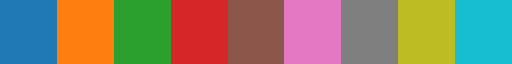

In [143]:
strain_cmap

## Compute p-values

In [144]:

# Collect p-values and corresponding (strain, metabolite) pairs
strain_metabolite_pairs = []
adjusted_p_values = []
all_p_values = []
uM_mean_std_dict = {}
for strain in exo_strains:
    p_values = []
    for metabolite in uM_metabolites:
        s_values = df_uMsamples.loc[strain, metabolite]
        wt_values = df_uMsamples.loc['WT', metabolite]
        s_mean = s_values.mean()
        wt_mean = wt_values.mean()
        s_std = s_values.std()
        wt_std = wt_values.std()
        uM_mean_std_dict[strain, metabolite] = {'Mean':s_mean, 'Std':s_std, 'N':len(s_values)}
        
        # if not np.isnan([s_mean, wt_mean, s_std, wt_std]).any():
        ttest_res = st.ttest_ind(s_values, wt_values, equal_var=False, alternative='two-sided')
        if not np.isnan(ttest_res.pvalue):
            p_values.append(ttest_res.pvalue)
            strain_metabolite_pairs.append((strain, metabolite))
        
    # Adjust p-values using the Benjamini-Hochberg procedure
    adjusted_p_values_s = multipletests(p_values, method='fdr_bh')[1]
    adjusted_p_values += adjusted_p_values_s.tolist()
    all_p_values += p_values
    # break
# Create a dictionary with adjusted p-values
adjusted_p_values_dict = {
    pair: adj_p for pair, adj_p in zip(strain_metabolite_pairs, adjusted_p_values)
}
p_values_dict = {
    pair: p_val for pair, p_val in zip(strain_metabolite_pairs, all_p_values)
}


In [145]:

# Collect p-values and corresponding (strain, metabolite) pairs
strain_metabolite_pairs = []
adjusted_p_values = []
all_p_values = []
counts_mean_std_dict = {}
all_mean_differences = {}
log_diffs = {}
for strain in exo_strains:
    p_values = []
    for metabolite in z_metabolites:
        s_values = df_counts_samples.loc[strain, metabolite]
        wt_values = df_counts_samples.loc['WT', metabolite]
        s_mean = s_values.mean()
        wt_mean = wt_values.mean()
        s_std = s_values.std()
        wt_std = wt_values.std()
        counts_mean_std_dict[strain, metabolite] = {'Mean':s_mean, 'Std':s_std, 'N':len(s_values)}
        # if not np.isnan([s_mean, wt_mean, s_std, wt_std]).any():
        if strain != 'WT':
            log_diffs[strain, metabolite] = np.log10(s_mean) - np.log10(wt_mean)
            all_mean_differences[strain, metabolite] = s_mean - wt_mean
        ttest_res = st.ttest_ind(s_values, wt_values, equal_var=False, alternative='two-sided')
        if not np.isnan(ttest_res.pvalue):
            p_values.append(ttest_res.pvalue)
            strain_metabolite_pairs.append((strain, metabolite))
        
        # print(strain, metabolite, ttest_res, s_values, wt_values)
    # Dont add WT vs WT in all the values
    # Adjust p-values using the Benjamini-Hochberg procedure
    adjusted_p_values_s = multipletests(p_values, method='fdr_bh')[1]
    adjusted_p_values += adjusted_p_values_s.tolist()
    all_p_values += p_values
    # break
# Create a dictionary with adjusted p-values
counts_adjusted_p_values_dict = {
    pair: adj_p for pair, adj_p in zip(strain_metabolite_pairs, adjusted_p_values)
}
counts_p_values_dict = {
    pair: p_val for pair, p_val in zip(strain_metabolite_pairs, all_p_values)
}


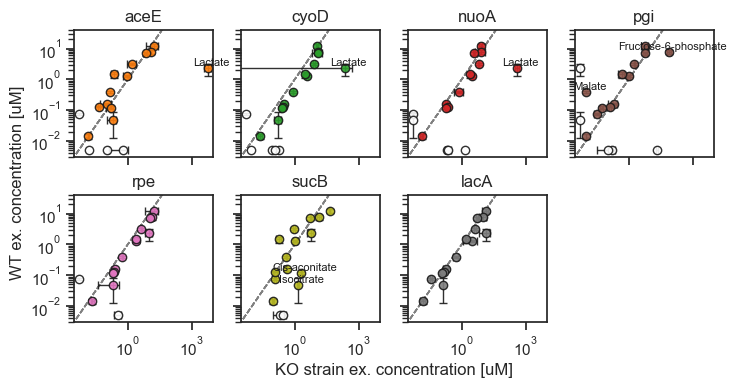

In [146]:
from matplotlib.ticker import LogLocator, NullFormatter

fig, axes = plt.subplots(2, 4, figsize=(8, 4), sharey=True, sharex = True)
axes = axes.flatten()
for i, strain in enumerate(exo_strains_x_wt):
    for j, m in enumerate(uM_metabolites):
        # print(strain, m)
        ax = axes[i]
        ax.set_title(strain)
        ax.set_xscale('log')
        ax.set_yscale('log')
        s_mean = uM_mean_std_dict[strain, m]['Mean']
        s_std = uM_mean_std_dict[strain, m]['Std']
        s_n = uM_mean_std_dict[strain, m]['N']
        wt_mean = uM_mean_std_dict['WT', m]['Mean']
        wt_std = uM_mean_std_dict['WT', m]['Std']
        wt_n = uM_mean_std_dict['WT', m]['N']

        if np.isnan(s_mean) and np.isnan(wt_mean):
            continue

        try:
            pvalue = p_values_dict[strain, m]
        except:
            pvalue = np.nan
        
        # if pvalue < 0.05:
        #     print(f'{strain} {m} {ttest_res.pvalue:.2e}')
        #     mecolor = 'k'
        # else:
        #     mecolor = 'gray'

        mecolor = 'k'
        if np.isnan(s_mean) or np.isnan(wt_mean):
            c = 'w'
            if np.isnan(s_mean):
                s_mean = 5e-3
            if np.isnan(wt_mean):
                wt_mean = 5e-3
        else:
            c = strain_colors[strain]


        ax.errorbar(
            x=s_mean,
            y = wt_mean,
            xerr=s_std,
            yerr=wt_std,
            fmt='o',
            # color='black',
            capsize=3,
            elinewidth=1,
            alpha=0.9,
            markeredgecolor=mecolor,
            ecolor=mecolor,#wt_mets_colors[m],
            c = c#strain_colors[strain],
        )
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ax.plot([1e-4, 1e3], [1e-4, 1e3], ls = '--',c = 'gray', alpha=0.5, zorder=-10, lw = 1)


        # Annotate
        if np.abs(np.log10(uM_mean_std_dict[strain, m]['Mean']) - np.log10(uM_mean_std_dict['WT', m]['Mean'])) > 1:
            ax.annotate(
                m,
                xy=(uM_mean_std_dict[strain, m]['Mean'], uM_mean_std_dict['WT', m]['Mean']),
                xytext=(uM_mean_std_dict[strain, m]['Mean']*1.5, uM_mean_std_dict['WT', m]['Mean']*1.5),
                fontsize=8,
                ha='center',
                va='center',
                color = 'k', #strain_colors[strain],
            )
        # ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(3e-3, 1e4)
        ax.set_ylim(3e-3, 4e1)
        # ax.set_ylim(-4, 4)
        # Increase the number of ticks on the x-axis
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=4))  # Major ticks
        # ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=6))  # Minor ticks

axes[-1].remove()
fig.supylabel('WT ex. concentration [uM]', fontsize=12)
fig.supxlabel('KO strain ex. concentration [uM]', fontsize=12)
# plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.3, left = 0.1, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_exometabolome_wt_comparison_v1.pdf', bbox_inches='tight')

# Repeat, but with counts

In [147]:
counts_mean_std_dict

{('WT', '1, 3-diaminopropane'): {'Mean': np.float64(3182.921074350143),
  'Std': 472.00262802840047,
  'N': 3},
 ('WT', '2, 5-dihydroxybenzoate'): {'Mean': np.float64(21305.54673111277),
  'Std': 3360.2592067157616,
  'N': 3},
 ('WT', '2-hydroxybutyrate'): {'Mean': np.float64(1245.8139064551399),
  'Std': 99.3774561686364,
  'N': 3},
 ('WT', '2-hydroxyglutaric acid'): {'Mean': np.float64(4703.135330552873),
  'Std': 396.5261877723813,
  'N': 3},
 ('WT', '2-oxobutanoate/acetoacetate'): {'Mean': nan, 'Std': nan, 'N': 3},
 ('WT',
  '3-(4-hydroxyphenyl)pyruvate'): {'Mean': np.float64(1780.4709022286434), 'Std': 68.94937548451763, 'N': 3},
 ('WT', '3-hydroxyanthranilate'): {'Mean': np.float64(7937.131061200321),
  'Std': 718.4786428236852,
  'N': 3},
 ('WT', '3-hydroxybutyrate'): {'Mean': np.float64(3182.3764590937267),
  'Std': 71.0512955006231,
  'N': 3},
 ('WT', '3-hydroxyglutaric acid'): {'Mean': np.float64(3818.45646063192),
  'Std': 1008.4370064940097,
  'N': 3},
 ('WT', '3-hydroxyphe

aceE 1, 3-diaminopropane (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 2923.2761165964134 3182.921074350143 0.6185867811373047 w
aceE 2, 5-dihydroxybenzoate (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 15102.641606100698 21305.54673111277 0.19127376073526775 w
aceE 2-hydroxybutyrate (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 14038.521429678447 1245.8139064551399 0.16138160636884796 w
aceE 2-hydroxyglutaric acid (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 15173.996578062333 4703.135330552873 0.07028783597262146 w
aceE 2-oxobutanoate/acetoacetate (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)) 6481.957968353466 nan nan gray
aceE 3-(4-hydroxyphenyl)pyruvate (np.float64(1.0), np.float64(0.4980392156862745), np.float

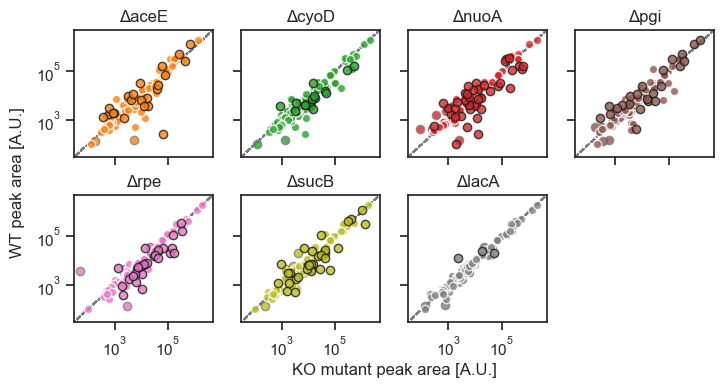

In [151]:
annotate = False
plot_nan = False
fig, axes = plt.subplots(2, 4, figsize=(8, 4), sharey=True, sharex = True)
axes = axes.flatten()
for i, strain in enumerate(exo_strains_x_wt):
    for j, m in enumerate(z_metabolites):
        ax = axes[i]
        ax.set_title(f'Δ{strain}')
        ax.set_xscale('log')
        ax.set_yscale('log')
        s_mean = counts_mean_std_dict[strain, m]['Mean']
        wt_mean = counts_mean_std_dict['WT', m]['Mean']
        
        c = strain_colors[strain]
        if plot_nan:
            if np.isnan(s_mean) or np.isnan(wt_mean):
                c = 'w'
                if np.isnan(s_mean):
                    s_mean = 10
                if np.isnan(wt_mean):
                    wt_mean = 10
        
        

        try:
            pvalue = counts_adjusted_p_values_dict[strain, m]
        except:
            pvalue = np.nan
        
        if pvalue < 0.05:
            # print(f'{strain} {m} {pvalue:.2e}')
            mecolor = 'k'
            zorder = 100
        elif np.isnan(pvalue):
            mecolor = 'gray'
            zorder = 0
        else:
            mecolor = 'w'
            zorder = 10
        print(strain, m, c, s_mean, wt_mean, pvalue, mecolor)

        # mecolor = 'k'
        ax.errorbar(
            x=s_mean,
            y=wt_mean,
            # xerr=counts_mean_std_dict[strain, m]['Std'],
            # yerr=counts_mean_std_dict['WT', m]['Std'],
            fmt='o',
            # color='black',
            capsize=3,
            elinewidth=1,
            alpha=0.8,
            markeredgecolor=mecolor,
            # ecolor=mecolor,#wt_mets_colors[m],
            markerfacecolor = c,#'gray',
            zorder=zorder,
        )
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ax.plot([1e-2, 1e7], [1e-2, 1e7], ls = '--',c = 'gray', alpha=0.5, zorder=-10, lw = 1)

        # Annotate
        if annotate:
            if np.abs(np.log10(s_mean) - np.log10(wt_mean)) > 1:
                ax.annotate(
                    m,
                    xy=(counts_mean_std_dict[strain, m]['Mean'], counts_mean_std_dict['WT', m]['Mean']),
                    xytext=(counts_mean_std_dict[strain, m]['Mean']*1.5, counts_mean_std_dict['WT', m]['Mean']*1.5),
                    fontsize=8,
                    ha='center',
                    va='center',
                    # fontweight='bold',
                    color = 'k', #strain_colors[strain],
                )
        # ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(30, 5e6)
        ax.set_ylim(30, 5e6)
        # ax.set_ylim(-4, 4)
        # Increase the number of ticks on the x-axis
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=4))  # Major ticks
        ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=4))  # Major ticks
        # ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=6))  # Minor ticks

axes[-1].remove()
fig.supylabel('WT peak area [A.U.]', fontsize=12)
fig.supxlabel('KO mutant peak area [A.U.]', fontsize=12)
# plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.3, left = 0.1, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_exometabolome_wt_comparison_v1_counts.pdf', bbox_inches='tight')

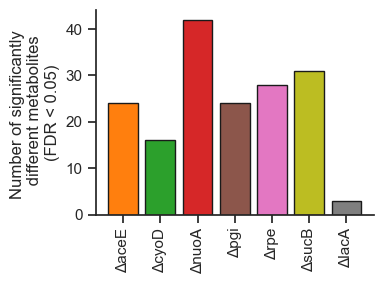

In [165]:

# Plot bar chart with the number of significant metabolites for each strain
significance_threshold = 0.05
n_sig = (
    df_counts_diffs[df_counts_diffs.Strain != 'WT']
    .groupby('Strain')
    .apply(lambda d: (d['adj. pvalue'] < significance_threshold).sum(), include_groups=False)
    .rename('N_significant')
    .reindex(exo_strains_x_wt)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(
    range(len(n_sig)),
    n_sig['N_significant'],
    color=[strain_colors[s] for s in n_sig['Strain']],
    edgecolor='k',
    linewidth=1,
)
ax.set_xticks(range(len(n_sig)))
ax.set_xticklabels([f'Δ{s}' for s in n_sig['Strain']], rotation=90, ha='center')
# ax.set_xlabel('Strain')
ax.set_ylabel('Number of significantly \n different metabolites\n(FDR < 0.05)')
# ax.set_title('Significant exometabolome changes per KO strain')
sns.despine()
plt.tight_layout()
plt.savefig(figure_folder / 'KEIO_n_significant_metabolites_per_strain.pdf', bbox_inches='tight')
plt.show()


# Print statistics

In [84]:
# Print statistics
counts_diffs = []
for i, strain in enumerate(exo_strains_x_wt):
    for j, m in enumerate(z_metabolites):
        try:
            pvalue = counts_adjusted_p_values_dict[strain, m]
        except:
            pvalue = np.nan
        # pvalue = counts_adjusted_p_values_dict[strain, m]
        s_mean = counts_mean_std_dict[strain, m]['Mean']
        wt_mean = counts_mean_std_dict['WT', m]['Mean']
        s_std = counts_mean_std_dict[strain, m]['Std']
        wt_std = counts_mean_std_dict['WT', m]['Std']
        if np.isnan(wt_mean) and not np.isnan(s_mean*s_std):
            pvalue = 1e-10
        counts_diffs.append((strain, m, pvalue, s_mean, wt_mean, s_std, wt_std))
df_counts_diffs = pd.DataFrame(counts_diffs, columns=['Strain', 'Metabolite', 'adj. pvalue', 'Strain_mean', 'WT_mean', 'Strain_std', 'WT_std'])

In [85]:
uM_diffs = []
for i, strain in enumerate(exo_strains_x_wt):
    for j, m in enumerate(uM_metabolites):
        try:
            pvalue = adjusted_p_values_dict[strain, m]
        except:
            pvalue = np.nan
        # pvalue = counts_adjusted_p_values_dict[strain, m]
        s_mean = uM_mean_std_dict[strain, m]['Mean']
        wt_mean = uM_mean_std_dict['WT', m]['Mean']
        s_std = uM_mean_std_dict[strain, m]['Std']
        wt_std = uM_mean_std_dict['WT', m]['Std']
        if np.isnan(wt_mean) and not np.isnan(s_mean*s_std):
            pvalue = 1e-10
        uM_diffs.append((strain, m, pvalue, s_mean, wt_mean, s_std, wt_std))
df_uM_diffs = pd.DataFrame(uM_diffs, columns=['Strain', 'Metabolite', 'adj. pvalue', 'Strain_mean', 'WT_mean', 'Strain_std', 'WT_std'])

In [86]:
df_uM_diffs['WT ref'] = [x if not np.isnan(x) else 0 for x in df_uM_diffs['WT_mean'] ]

In [87]:
df_uM_diffs['Difference'] = df_uM_diffs['Strain_mean'] - df_uM_diffs['WT ref']

In [88]:

df_uM_diffs.sort_values('Difference', ascending=False).head(20)

,Strain,Metabolite,adj. pvalue,Strain_mean,WT_mean,Strain_std,WT_std,WT ref,Difference
13,aceE,Lactate,1.183845e-01,5738.903655,2.261028,2034.525794,0.943209,2.261028,5736.642627
51,nuoA,Lactate,2.755500e-02,387.567520,2.261028,72.165452,0.943209,2.261028,385.306492
32,cyoD,Lactate,3.031223e-01,219.871394,2.261028,255.302359,0.943209,2.261028,217.610365
64,pgi,Fructose-6-phosphate,3.354869e-02,78.869484,7.735606,17.284474,1.317779,7.735606,71.133879
101,sucB,Citrate,1.126798e-03,43.715313,12.512888,2.552066,1.992018,12.512888,31.202425
66,pgi,Glucose-6-phosphate,1.000000e-10,20.689664,NaN,2.345093,NaN,0.000000,20.689664
127,lacA,Lactate,3.135969e-01,13.692189,2.261028,7.368799,0.943209,2.261028,11.431161
89,rpe,Lactate,7.219963e-02,9.687793,2.261028,3.554023,0.943209,2.261028,7.426764
102,sucB,Fructose-6-phosphate,5.480013e-02,13.862113,7.735606,2.532979,1.317779,7.735606,6.126507
83,rpe,Fructose-6-phosphate,1.052639e-01,13.261023,7.735606,3.478979,1.317779,7.735606,5.525417


In [89]:
p_values_dict['aceE', 'Lactate']

np.float64(0.03946148607440755)

In [90]:
# Get the top 5 significant metabolites (lowest adj. pvalue) for each strain
top5_metabolites = (
    df_uM_diffs
    .sort_values(['Strain', 'adj. pvalue'])
    .groupby('Strain')
    .head(5)
    .reset_index(drop=True)
)
display(top5_metabolites[['Strain', 'Metabolite', 'adj. pvalue']])# Get the top 5 significant metabolites (lowest adj. pvalue) for each strain


,Strain,Metabolite,adj. pvalue
0,aceE,Valine,1.000000e-10
1,aceE,Fructose-6-phosphate,1.183845e-01
2,aceE,Gamma-aminobutyrate,1.183845e-01
3,aceE,Lactate,1.183845e-01
4,aceE,Leucine,1.474249e-01
5,cyoD,Glutamine,1.000000e-10
6,cyoD,Valine,1.000000e-10
7,cyoD,Malate,8.272377e-03
8,cyoD,Alanine,2.713135e-02
9,cyoD,Cis-aconitate,2.713135e-02


In [91]:
# Get the top 5 significant metabolites (lowest adj. pvalue) for each strain
top5_metabolites = (
    df_counts_diffs
    .sort_values(['Strain', 'adj. pvalue'])
    .groupby('Strain')
    .head(5)
    .reset_index(drop=True)
)
display(top5_metabolites[['Strain', 'Metabolite', 'adj. pvalue']])# Get the top 5 significant metabolites (lowest adj. pvalue) for each strain


,Strain,Metabolite,adj. pvalue
0,aceE,2-oxobutanoate/acetoacetate,1.000000e-10
1,aceE,Pyruvate,1.000000e-10
2,aceE,3-hydroxybutyrate,2.621170e-04
3,aceE,cAMP,1.391094e-03
4,aceE,Ethanolamine,2.162208e-02
5,cyoD,Oxoproline,1.396029e-02
6,cyoD,2-hydroxyglutaric acid,2.759011e-02
7,cyoD,3-hydroxyglutaric acid,2.759011e-02
8,cyoD,Adenosine,2.759011e-02
9,cyoD,Malate,2.759011e-02


In [92]:
# Calculate the fraction of significant metabolites for each strain
significance_threshold = 0.05
fraction_significant = (
    df_counts_diffs
    .groupby('Strain')
    .apply(lambda df: (df['adj. pvalue'] < significance_threshold).mean())
    .rename('Fraction_significant')
    .reset_index()
)
display(fraction_significant)

# Calculate the fraction of significant metabolites for each strain
significance_threshold = 0.05
N_significant = (
    df_counts_diffs
    .groupby('Strain')
    .apply(lambda df: (df['adj. pvalue'] < significance_threshold).sum())
    .rename('N_significant')
    .reset_index()
)
display(N_significant)
print(df_counts_diffs.Metabolite.nunique())

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_8651/879466117.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: (df['adj. pvalue'] < significance_threshold).mean())


,Strain,Fraction_significant
0,aceE,0.216216
1,cyoD,0.144144
2,lacA,0.027027
3,nuoA,0.378378
4,pgi,0.216216
5,rpe,0.252252
6,sucB,0.279279


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_8651/879466117.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: (df['adj. pvalue'] < significance_threshold).sum())


,Strain,N_significant
0,aceE,24
1,cyoD,16
2,lacA,3
3,nuoA,42
4,pgi,24
5,rpe,28
6,sucB,31


111


In [93]:
22/111


0.1981981981981982

In [94]:
df_log_diffs = pd.Series(log_diffs).reset_index()
df_log_diffs.columns = ['Strain', 'Metabolite', 'LogDiff']

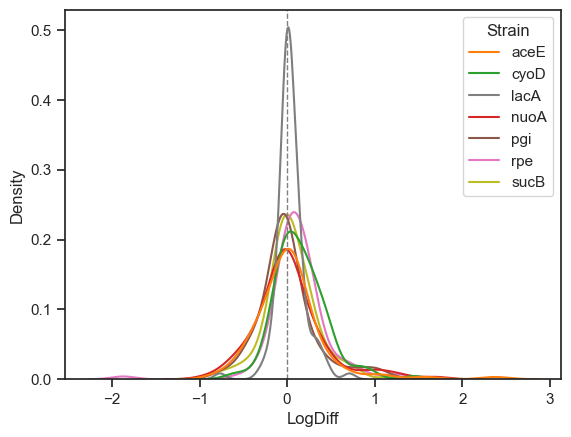

In [95]:
# log_diff = 
ax = sns.kdeplot(data = df_log_diffs, x = 'LogDiff', hue = 'Strain', palette=strain_colors)
ax.axvline(0, ls = '--', c = 'gray', lw = 1)


In [96]:
df_log_diffs.dropna(inplace=True)

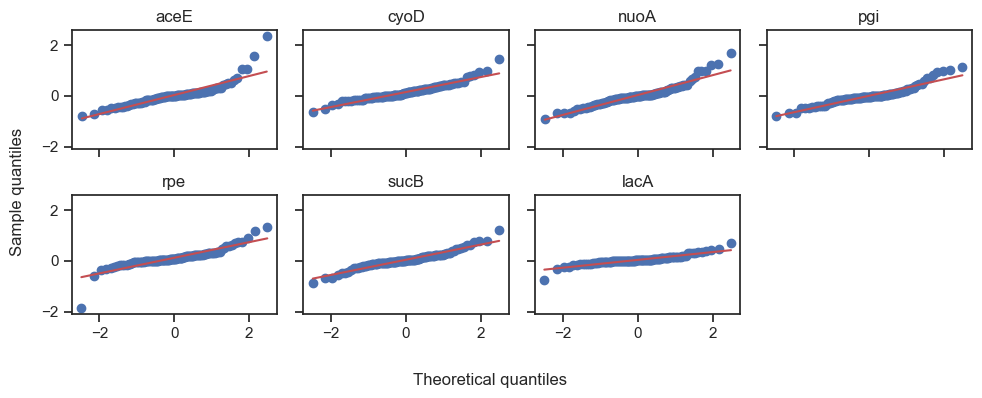

In [97]:
fig, axes = plt.subplots(2, 4, figsize=(10, 4), sharex=True, sharey=True)
axes = axes.flatten()
for i, strain in enumerate(exo_strains_x_wt):
    ax = axes[i]
    df_log_diffs_s = df_log_diffs.loc[df_log_diffs.Strain == strain]
    # print(df_log_diffs_s)
    # print(st.probplot(df_log_diffs_s.LogDiff, dist="norm", plot=plt, ))
    st.probplot(df_log_diffs_s.LogDiff, dist="norm", plot=ax, fit = True)#, rvalue=True)
    ax.set_title(strain)
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_xlim(-3, 3)
    # ax.set_ylim(-3, 3)
fig.supxlabel('Theoretical quantiles', fontsize=12)
fig.supylabel('Sample quantiles', fontsize=12)
axes[-1].remove()
plt.tight_layout()
# st.probplot(df_log_diffs.LogDiff, dist="norm", plot=plt, )

In [98]:

wt_mets = sorted(df_uM.loc[df_uM.Strain == 'WT', df_uM.loc[df_uM.Strain == 'WT'].notna().any()].columns[1:-4])

In [99]:
mets_cmap = plt.get_cmap('tab20', len(wt_mets))
wt_mets_colors = {m: mets_cmap(i) for i, m in enumerate(wt_mets)}

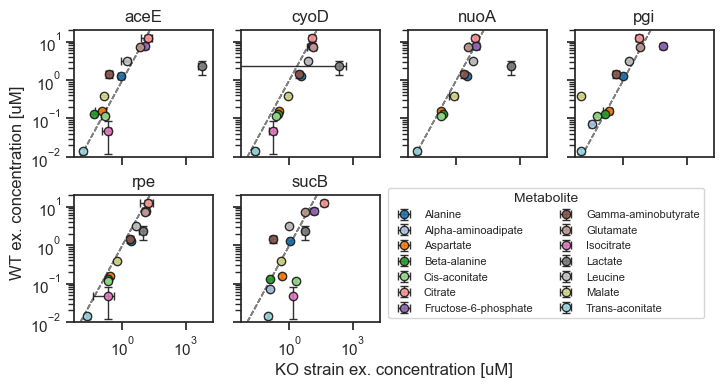

In [100]:
from matplotlib.ticker import LogLocator, NullFormatter

fig, axes = plt.subplots(2, 4, figsize=(8, 4), sharey=True, sharex = True)
axes = axes.flatten()
for i, strain in enumerate(exo_strains_x_wt):
    if strain == 'lacA':
        continue
    for j, m in enumerate(uM_metabolites):
        ax = axes[i]
        ax.set_title(strain)
        ax.set_xscale('log')
        ax.set_yscale('log')
        x_mean = uM_mean_std_dict[strain, m]['Mean']
        y_mean = uM_mean_std_dict['WT', m]['Mean']
        if np.isnan(x_mean) or np.isnan(y_mean):
            continue
        ax.errorbar(
            x=x_mean,
            y=y_mean,
            xerr=uM_mean_std_dict[strain, m]['Std'],
            yerr=uM_mean_std_dict['WT', m]['Std'],
            fmt='o',
            # color='black',
            capsize=3,
            elinewidth=1,
            alpha=0.9,
            markeredgecolor='k',
            ecolor='k',#wt_mets_colors[m],
            c = wt_mets_colors[m],
            label = m,
        )
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ax.plot([1e-2, 1e3], [1e-2, 1e3], ls = '--',c = 'gray', alpha=0.5, zorder=-10, lw = 1)

        # ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(5e-3, 2e4)
        ax.set_ylim(1e-2, 2e1)
        # ax.set_ylim(-4, 4)
        # Increase the number of ticks on the x-axis
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=4))  # Major ticks
        # ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=6))  # Minor ticks

axes[-3].legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1.1),
    fontsize=8,
    title='Metabolite',
    title_fontsize='10',
    frameon=True,
    ncol=2,
)
axes[-1].remove()
axes[-2].remove()

fig.supylabel('WT ex. concentration [uM]', fontsize=12)
fig.supxlabel('KO strain ex. concentration [uM]', fontsize=12)
# plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.3, left = 0.1, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_exometabolome_wt_comparison_v2.pdf', bbox_inches='tight')

## PCA of z_score


In [101]:
X_df = df_z_scores_samples[z_metabolites].copy()

In [102]:
X_df = X_df.apply(lambda col: col.fillna(col.min()), axis = 0)

In [103]:
X = StandardScaler().fit_transform(X_df)

pca = PCA(n_components=2)
Xn = pca.fit_transform(X)
pca_df = pd.DataFrame(
    data = Xn,
    columns = ['PC1', 'PC2'],
    index = df_z_scores_samples.Sample_id,
)
pca_df['Strain'] = df_z_scores_samples.Strain.values


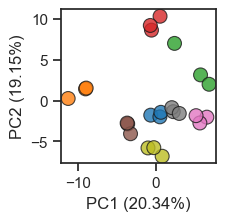

In [104]:
fig, ax = plt.subplots(figsize=(2, 2))
pca_df.sort_values(by = 'Strain', inplace=True)
sns.scatterplot(
    data = pca_df,
    x = 'PC1',
    y = 'PC2',
    hue = 'Strain',
    palette = strain_colors,
    alpha = 0.8,
    edgecolor = 'k',
    s = 100,
    ax=ax,
    legend=False,
    )
ax.set_xlabel('PC1 (%.2f%%)' % (pca.explained_variance_ratio_[0] * 100))
ax.set_ylabel('PC2 (%.2f%%)' % (pca.explained_variance_ratio_[1] * 100))
# sns.despine()
plt.savefig(figure_folder / 'KEIO_exometabolome_pca.pdf', bbox_inches='tight')

# Plot growth curves and yield from tubes

In [105]:
df_od_tubes = pd.read_csv(fn_tubes, index_col=0)
df_od_tubes.rename(columns={'Hours': 'Time [h]'}, inplace=True) 

# only keep data fro strains we did exomtabolome on
df_od_tubes = df_od_tubes.loc[df_od_tubes.Strain.isin(exo_strains)]

# strains = sorted(df_od_tubes.Strain.unique())
replicates = ['A', 'B', 'C']

yield_df = df_od_tubes.groupby(['Strain', 'Replicate']).agg({'OD600': 'max'}).reset_index()

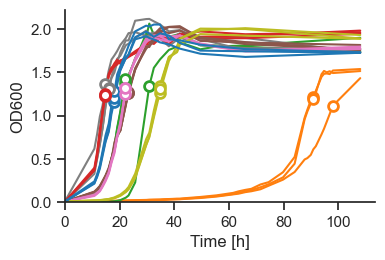

In [166]:
fig, ax = plt.subplots(figsize=(4, 2.5))
ax = sns.lineplot(data = df_od_tubes, x = 'Time [h]', y = 'OD600', hue = 'Strain',# style = 'Replicate',
                   palette = strain_colors, markers=True, units='Replicate', estimator=None, legend=False)# marker = 'o')
# sns.move_legend(ax, loc = 'upper left', bbox_to_anchor=(1, 1), title = 'Strain', fontsize = 10)
for strain in exo_strains:
    for replicate in replicates:
        idx = (df_uM.Strain == strain) & ( df_uM.Replicate == replicate)
        time = df_uM.loc[idx, 'Hours'].values[0]
        od = df_uM.loc[idx, 'OD'].values[0]
        ax.scatter(
            x = time,
            y = od,
            color = 'w',
            marker = 'o',
            s = 50,
            edgecolor = strain_colors[strain],
            linewidth = 2,
            zorder = 100

            # label = f'{strain} {replicate}',
        )

# plt.yscale('log')
sns.despine()
ax.set_ylim(0)
ax.set_xlim(0)
plt.savefig(figure_folder / '2A_screening_tubes_OD.pdf', bbox_inches='tight')

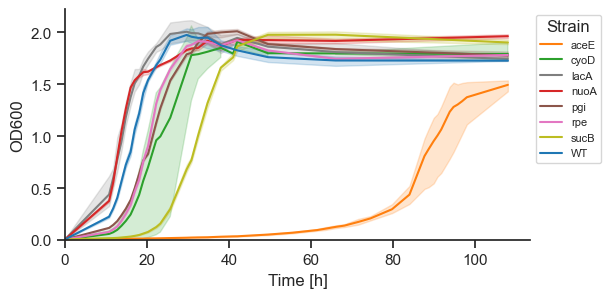

In [107]:
fig, ax = plt.subplots(figsize=(6, 3))
ax = sns.lineplot(data = df_od_tubes, x = 'Time [h]', y = 'OD600', hue = 'Strain', 
                  palette = strain_colors)
sns.move_legend(ax, loc = 'upper left', bbox_to_anchor=(1, 1), title = 'Strain', fontsize = 8)
sns.despine()
ax.set_ylim(0)
ax.set_xlim(0)
plt.savefig(figure_folder / '2A_screening_tubes_OD_error_band.pdf', bbox_inches='tight')

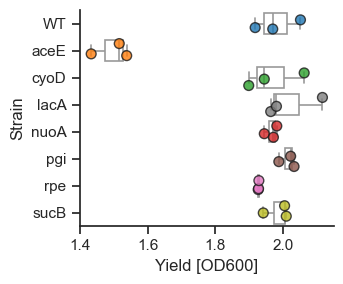

In [108]:

g = sns.catplot(data = yield_df, y = 'Strain', x = 'OD600',hue = 'Strain', 
                aspect=1.2, s = 50, height=3, alpha = 0.8, jitter = 0.3, edgecolor='k',
                  linewidth = 1, palette=strain_colors, order=exo_strains)
g.map_dataframe(sns.boxplot, y = 'Strain', x = 'OD600', color = 'w', fliersize = 0, linewidth = 1.2)
g.set_axis_labels('Yield [OD600]', 'Strain')
plt.savefig(figure_folder / 'strain_yield.pdf', bbox_inches='tight')

### Get growth rates

In [109]:
df_od_tubes

,Sample ID,Strain,Time [h],OD600,Replicate
0,1A,aceE,0.0,0.008,A
1,1B,aceE,0.0,0.003,B
2,1C,aceE,0.0,0.007,C
3,2A,cyoD,0.0,0.009,A
4,2B,cyoD,0.0,0.006,B
...,...,...,...,...,...
1375,8B,sucB,108.0,1.891,B
1376,8C,sucB,108.0,1.887,C
1383,11A,WT,108.0,1.726,A
1384,11B,WT,108.0,1.727,B


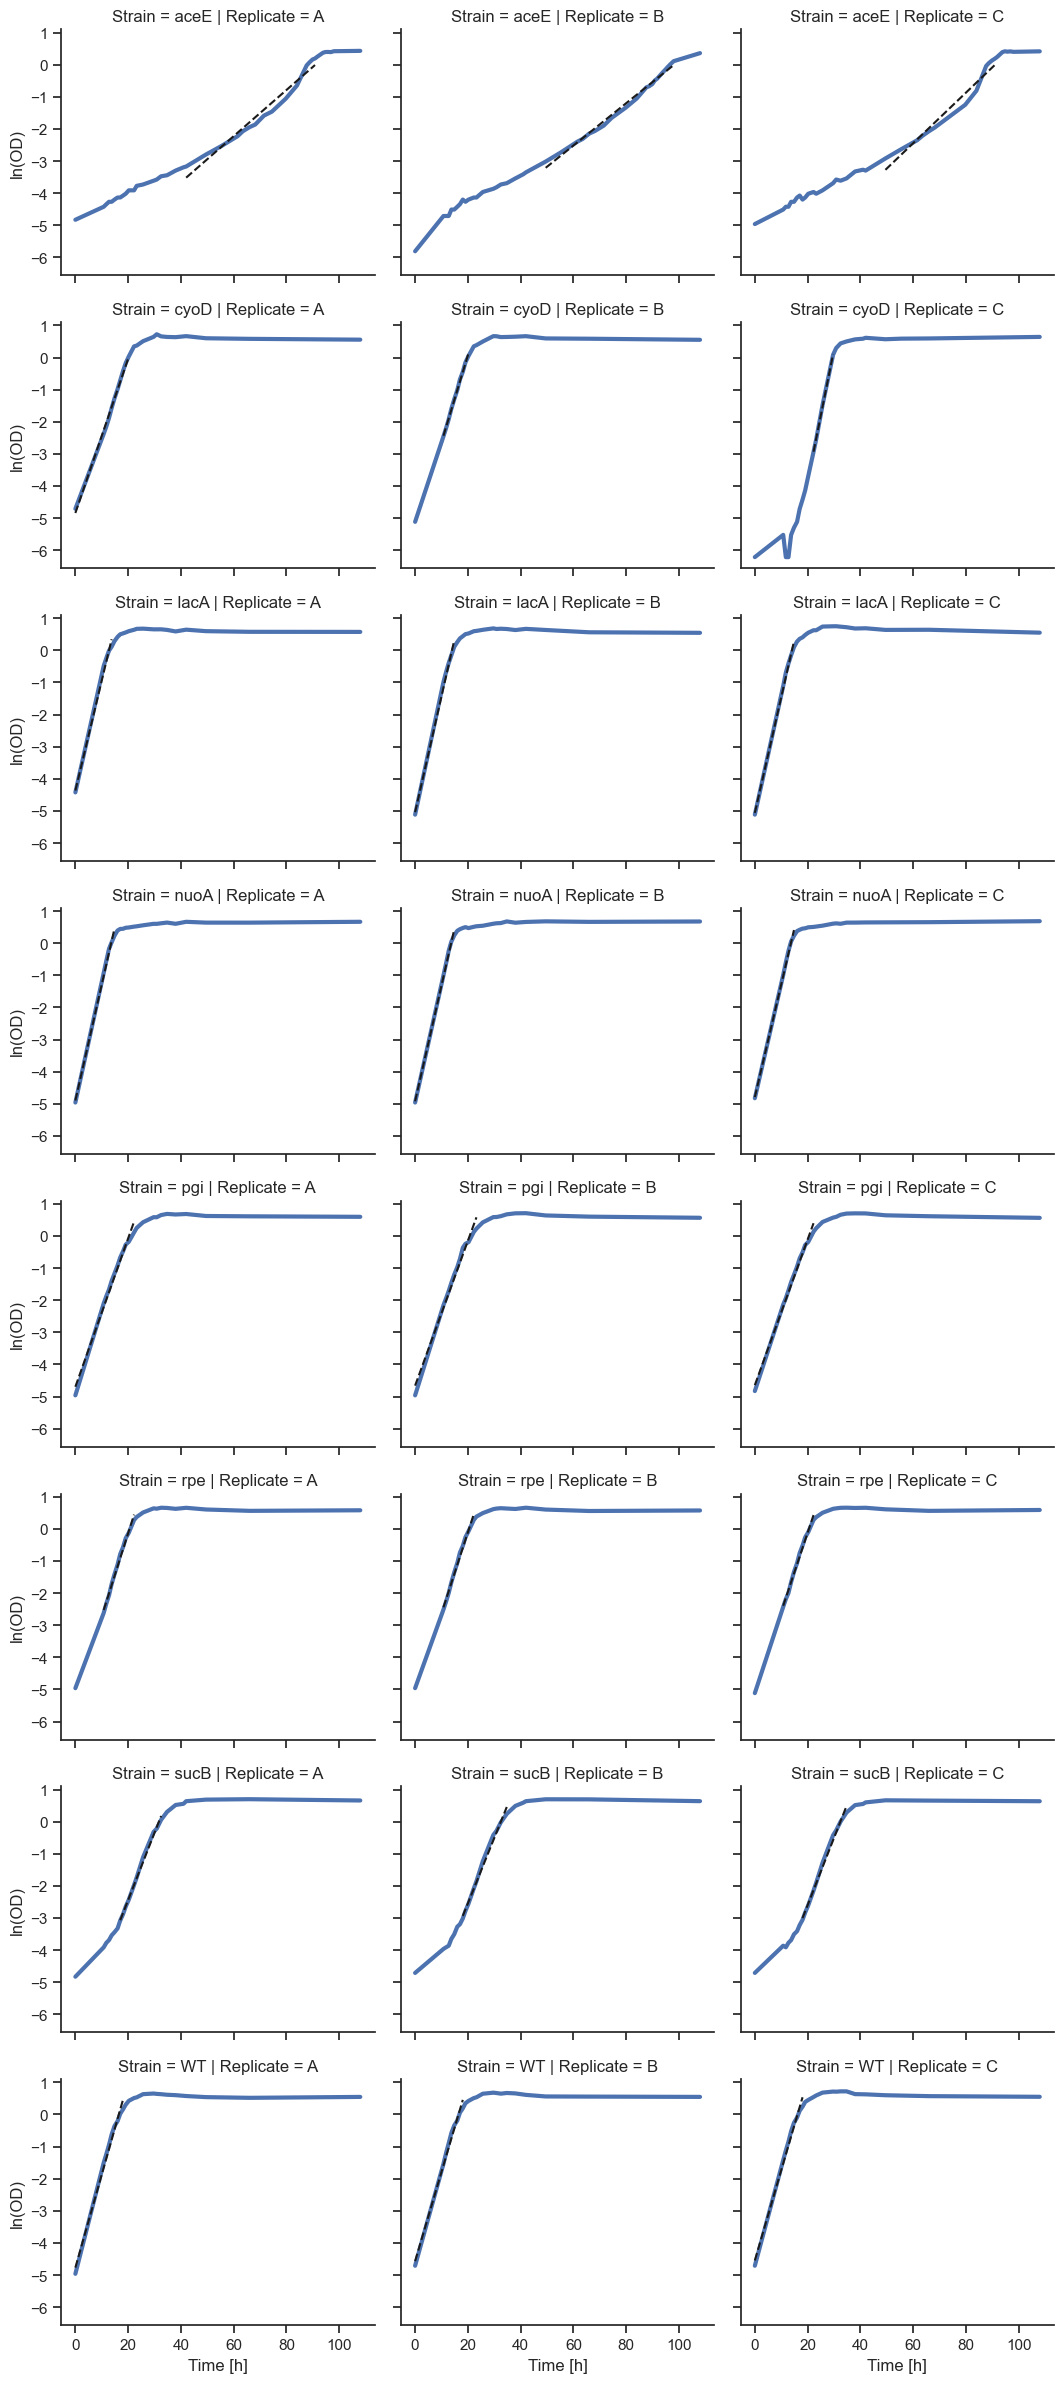

In [110]:
df_od_tubes['ln(OD)'] = np.log([x for x in df_od_tubes['OD600']])
g = sns.relplot(data=df_od_tubes, x = 'Time [h]', y = 'ln(OD)', row = 'Strain', col = 'Replicate', kind = 'line', lw = 3, height = 3, aspect = 1.2)
data = []
od_range = [0.05, 1.2]
for sample_id in df_od_tubes['Sample ID'].unique():
    idx = (df_od_tubes['Sample ID']==sample_id)
    dfi = df_od_tubes.loc[idx]
    strain = dfi.Strain.iloc[0]
    rep = sample_id[-1]
    ax = g.axes_dict[(strain, rep)]
    
    idx0 = (dfi['OD600']-od_range[0]).abs().argmin()
    idx1 = (dfi['OD600']-od_range[1]).abs().argmin()
    
    ln_OD = dfi.iloc[idx0:idx1+1]['ln(OD)']
    hours = dfi.iloc[idx0:idx1+1]['Time [h]']
    fit = np.polyfit(hours, ln_OD, 1)
    x_arr = np.linspace(hours.min(), hours.max(), 2)
    y_arr = x_arr*fit[0]+fit[1]
    # delta_ln_OD = - dfi.iloc[idx0]['ln(OD)']
    # delta_t = dfi.Hours.iloc[idx1]-dfi.Hours.iloc[idx0]
    # growth_rate = delta_ln_OD/delta_t
    growth_rate = fit[0]
    data.append([strain, rep, growth_rate])

    # Plot
    # ax.plot([dfi.Hours.iloc[idx0], dfi.Hours.iloc[idx1]], [dfi.iloc[idx0]['ln(OD)'], dfi.iloc[idx1]['ln(OD)']], c = 'k', ls = '--')
    ax.plot(x_arr, y_arr, c = 'k', ls = '--')
    
df_tube_rate = pd.DataFrame(data, columns = ['Strain', 'Replicate', 'Growth rate'])       

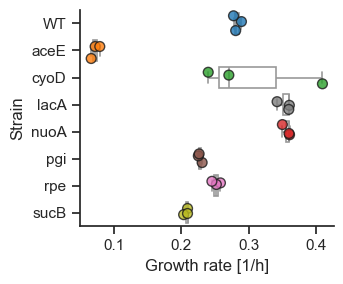

In [111]:



g = sns.catplot(df_tube_rate, x = 'Growth rate', y = 'Strain', hue = 'Strain', order = exo_strains, palette=strain_colors,
                aspect=1.2, s = 50, height=3, alpha = 0.8, jitter = 0.3, edgecolor='k',
                  linewidth = 1)
g.map_dataframe(sns.boxplot, y = 'Strain', x = 'Growth rate', color = 'w', fliersize = 0, linewidth = 1.2)
g.set_axis_labels('Growth rate [1/h]', 'Strain')
plt.savefig(figure_folder / 'strain_rate.pdf', bbox_inches='tight')

# Plot metabolomics data

In [112]:
# Make long data frame
dfL_counts = pd.melt(df_counts_samples.reset_index(), id_vars=['Strain', 'Sample_id'], var_name='Metabolite', value_name='Counts', value_vars=z_metabolites)
dfL_uM = pd.melt(df_uMsamples.reset_index(), id_vars=['Strain', 'Sample_id'], var_name='Metabolite', value_name='Concentration [uM]', value_vars=uM_metabolites)

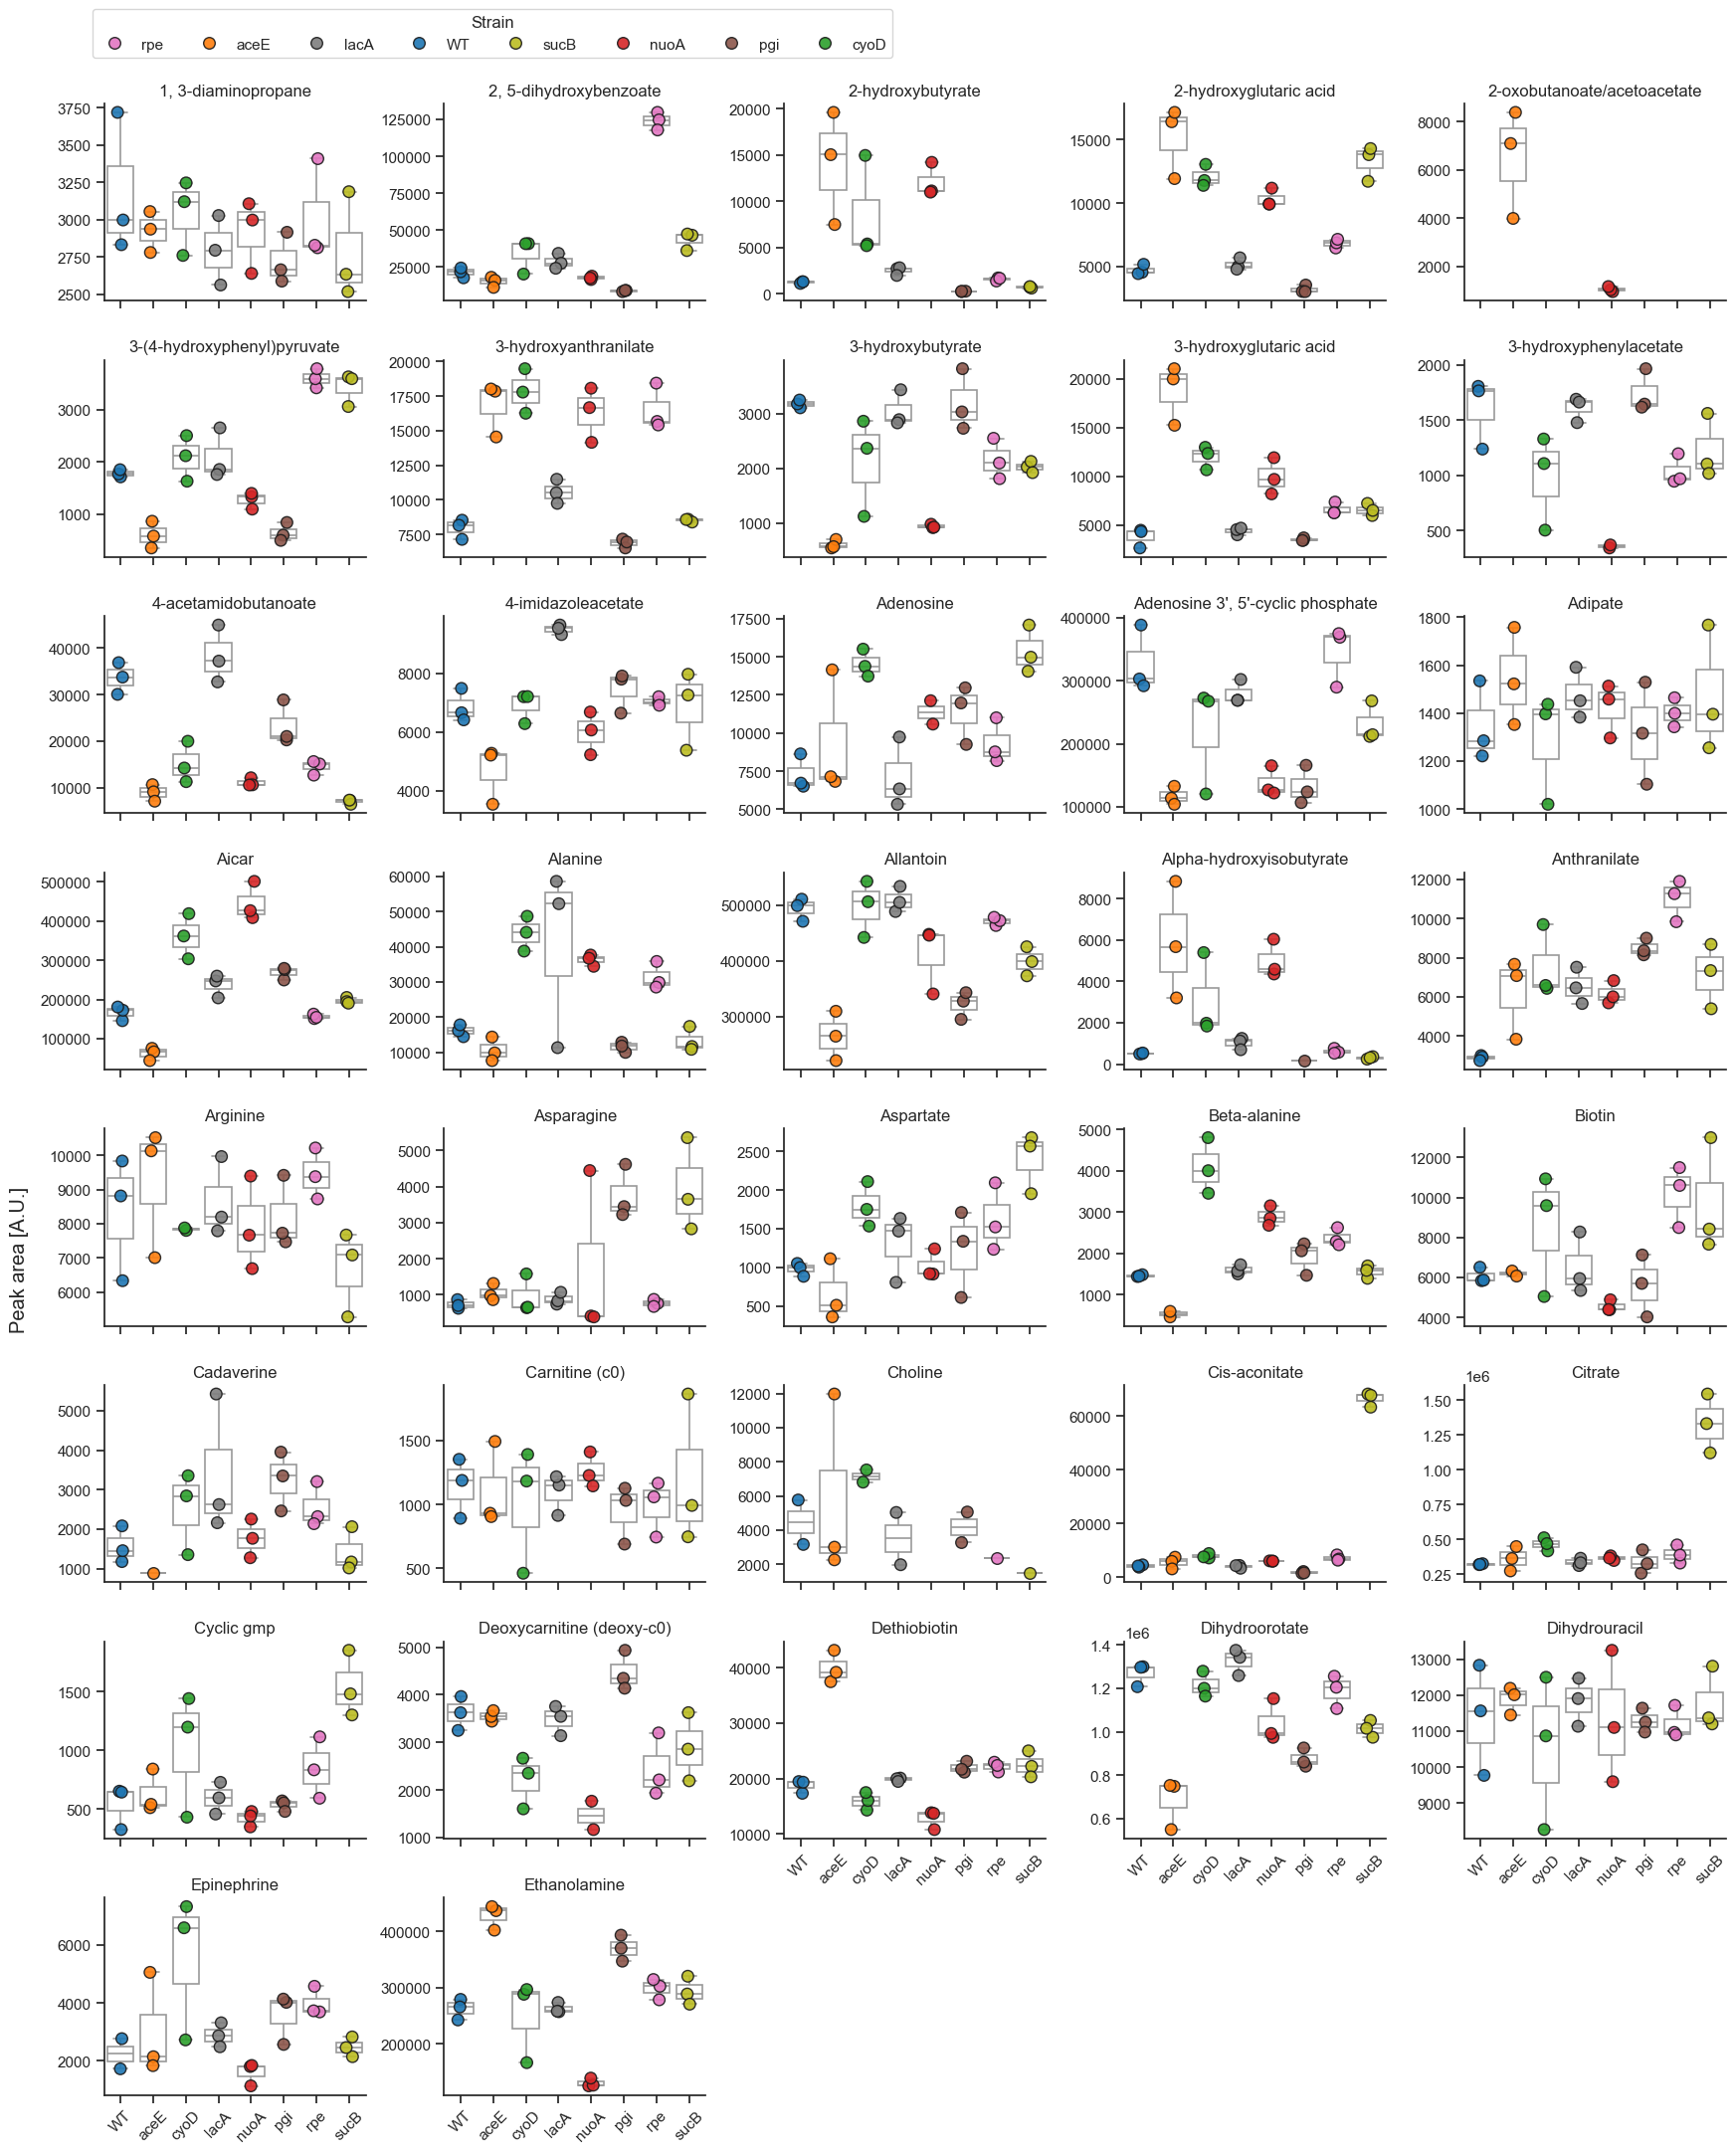

In [113]:
# sns.set_theme(font_scale=1.2, style='ticks')
n3 = int(len(z_metabolites)/3)
first = z_metabolites[:n3]
second = z_metabolites[n3:2*n3]
third = z_metabolites[2*n3:]
idx1 = dfL_counts.Metabolite.isin(first)
g = sns.catplot(data = dfL_counts.loc[idx1], x = 'Strain', y = 'Counts', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=5, sharey=False, s = 70, alpha = 0.9, linewidth = 1, edgecolor='k',height=3, aspect=1.2,legend = True)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Counts',color = 'w', fliersize = 0, linewidth = 1.2)
g.set_titles(col_template="{col_name}")
# Rotate x-tick labels for all axes
for ax in g.axes.flat:
    # if (ax.get_ylim()[1]/ax.get_ylim()[0] > 10) or ((ax.get_ylim()[0] <=0) and (ax.get_ylim()[1] > 100)):
    # ax.set_yscale('log')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('center')
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0.06,1), ncol = 8, frameon = True)
g.set_axis_labels('', '')
g.fig.supylabel('Peak area [A.U.]')
plt.subplots_adjust(wspace=0.3, hspace=0.3, left = 0.07, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_1.pdf', bbox_inches='tight')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_1.png', bbox_inches='tight', dpi = 300)

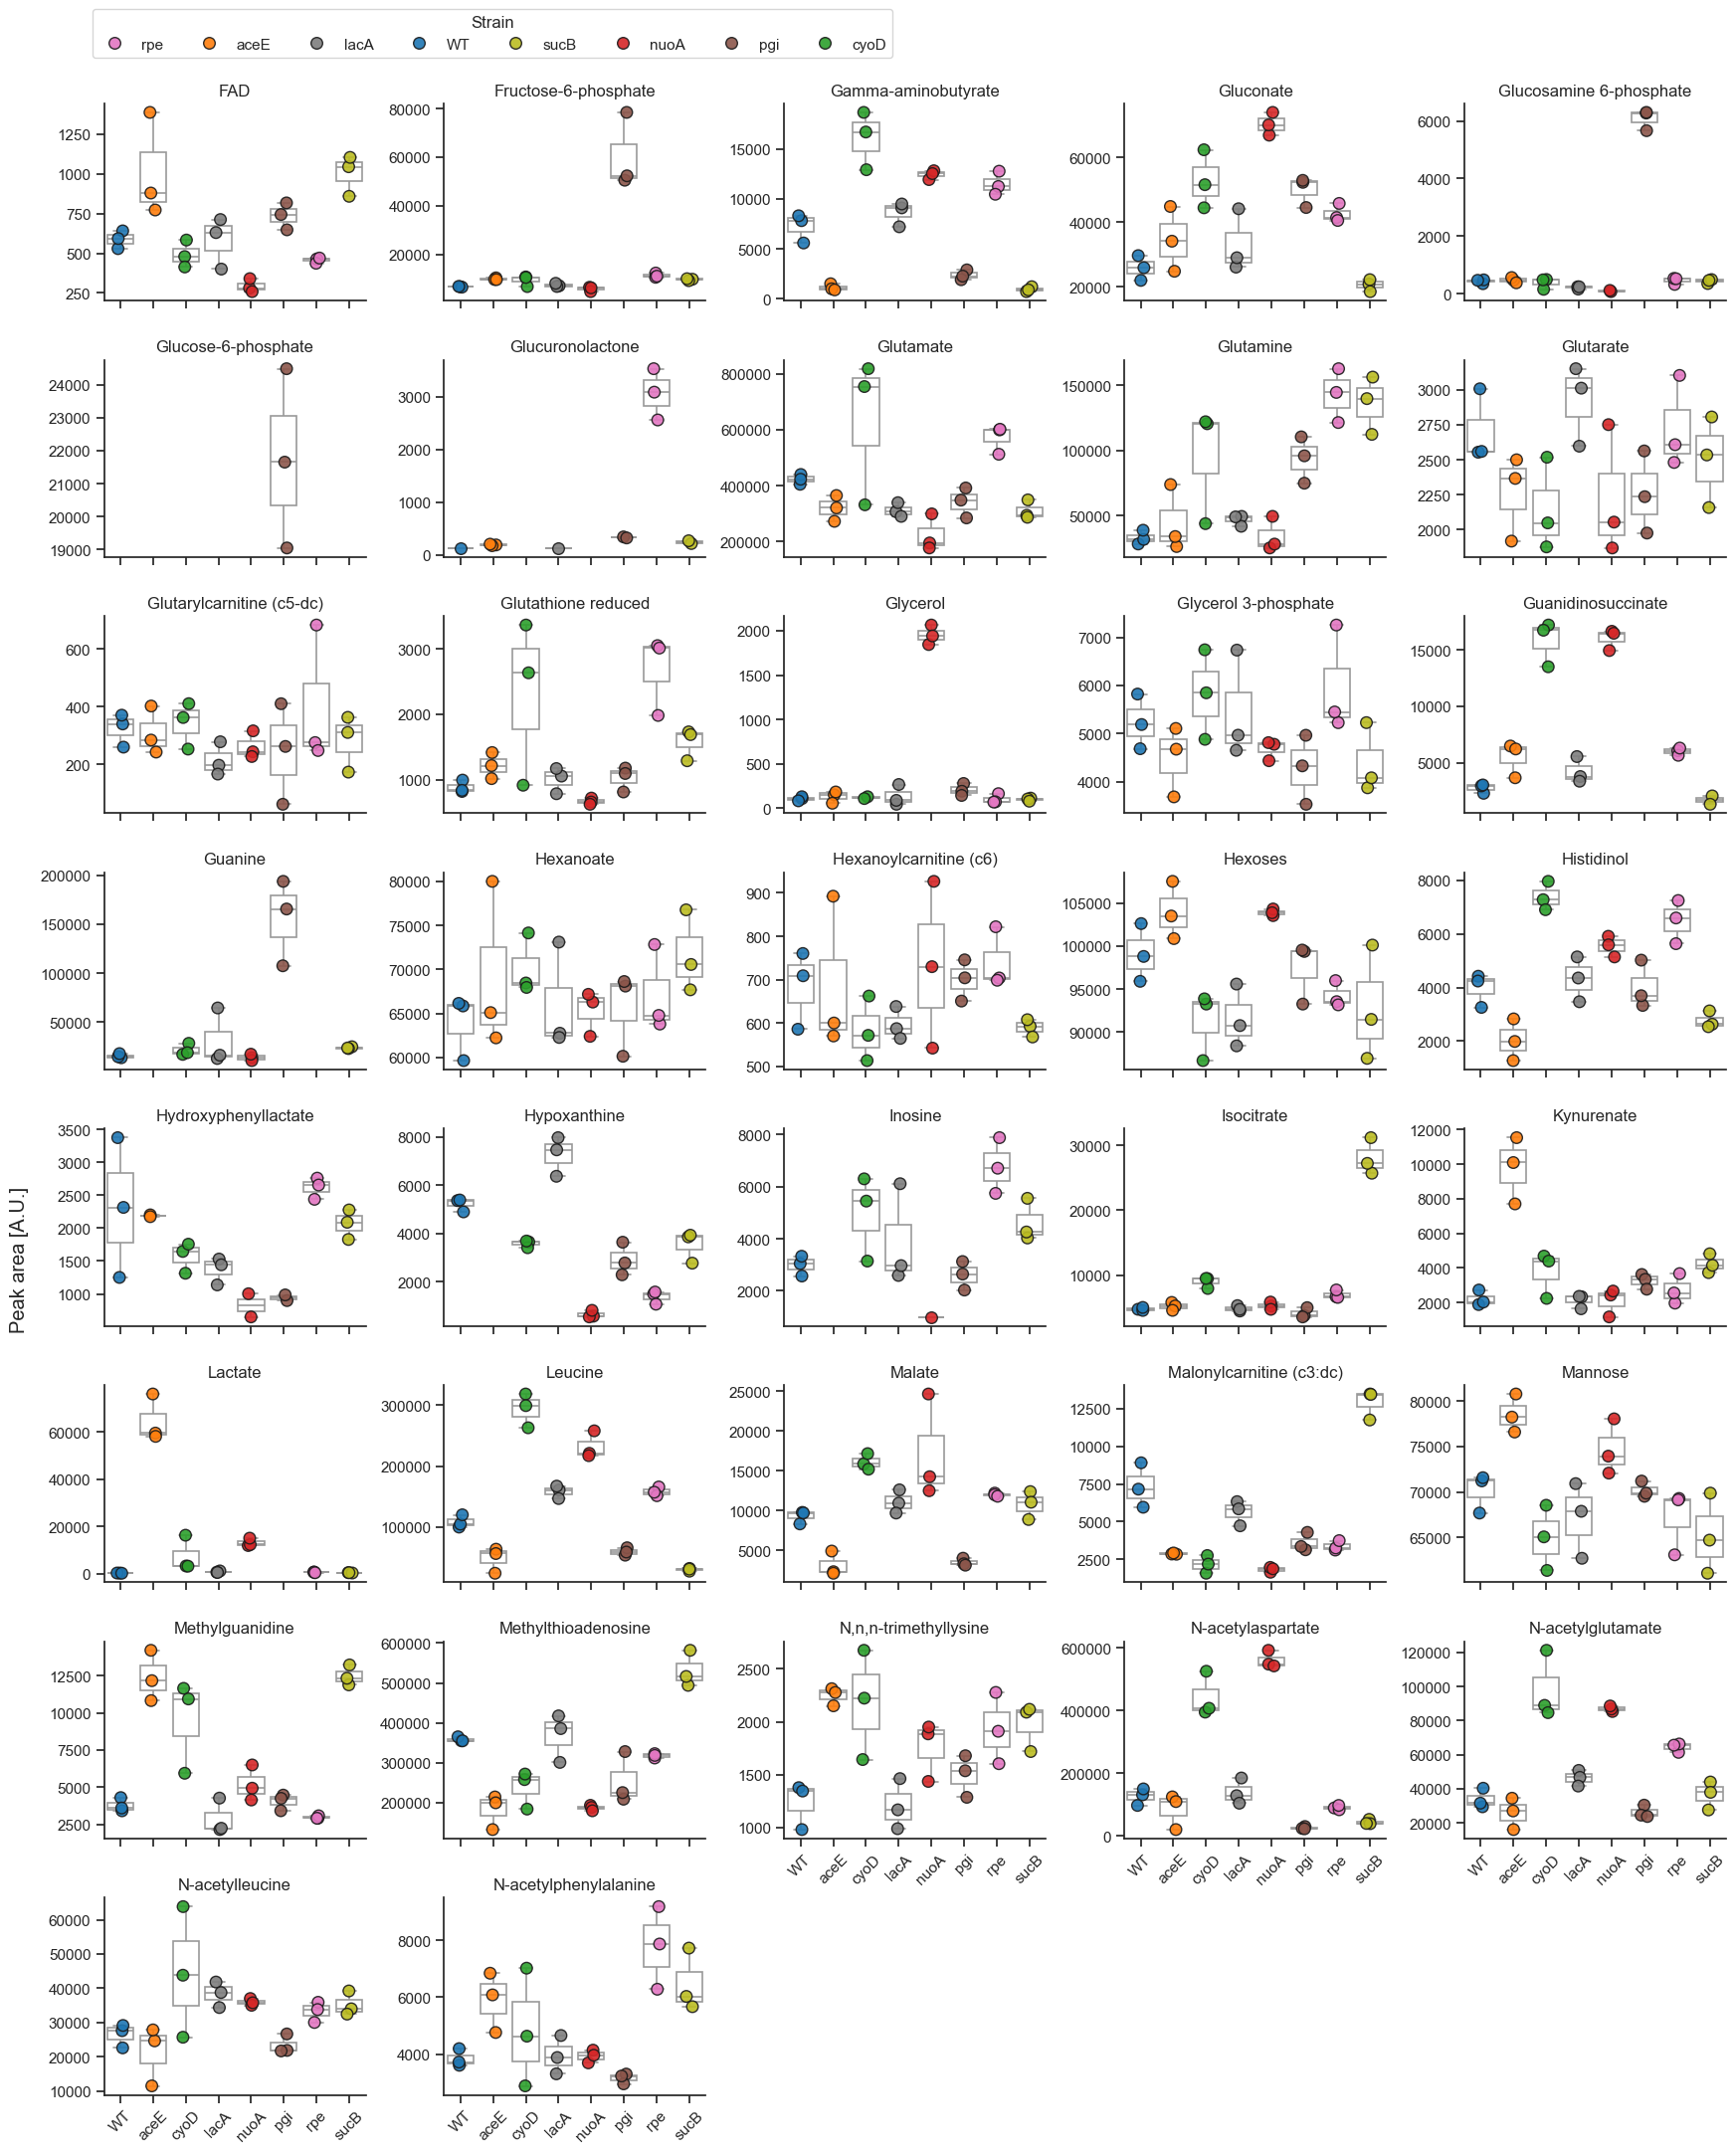

In [114]:
# sns.set_theme(font_scale=1.2, style='ticks')
idx2 = dfL_counts.Metabolite.isin(second)

g = sns.catplot(data = dfL_counts.loc[idx2], x = 'Strain', y = 'Counts', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=5, sharey=False, s = 70, alpha = 0.9, linewidth = 1, edgecolor='k',height=3, aspect=1.2,legend = True)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Counts',color = 'w', fliersize = 0, linewidth = 1.2)
g.set_titles(col_template="{col_name}")
# Rotate x-tick labels for all axes
for ax in g.axes.flat:
    # if (ax.get_ylim()[1]/ax.get_ylim()[0] > 10) or ((ax.get_ylim()[0] <=0) and (ax.get_ylim()[1] > 100)):
    # ax.set_yscale('log')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('center')
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0.06,1), ncol = 8, frameon = True)

g.set_axis_labels('', '')
g.fig.supylabel('Peak area [A.U.]')
plt.subplots_adjust(wspace=0.3, hspace=0.3, left = 0.07, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_2.pdf', bbox_inches='tight')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_2.png', bbox_inches='tight', dpi = 300)

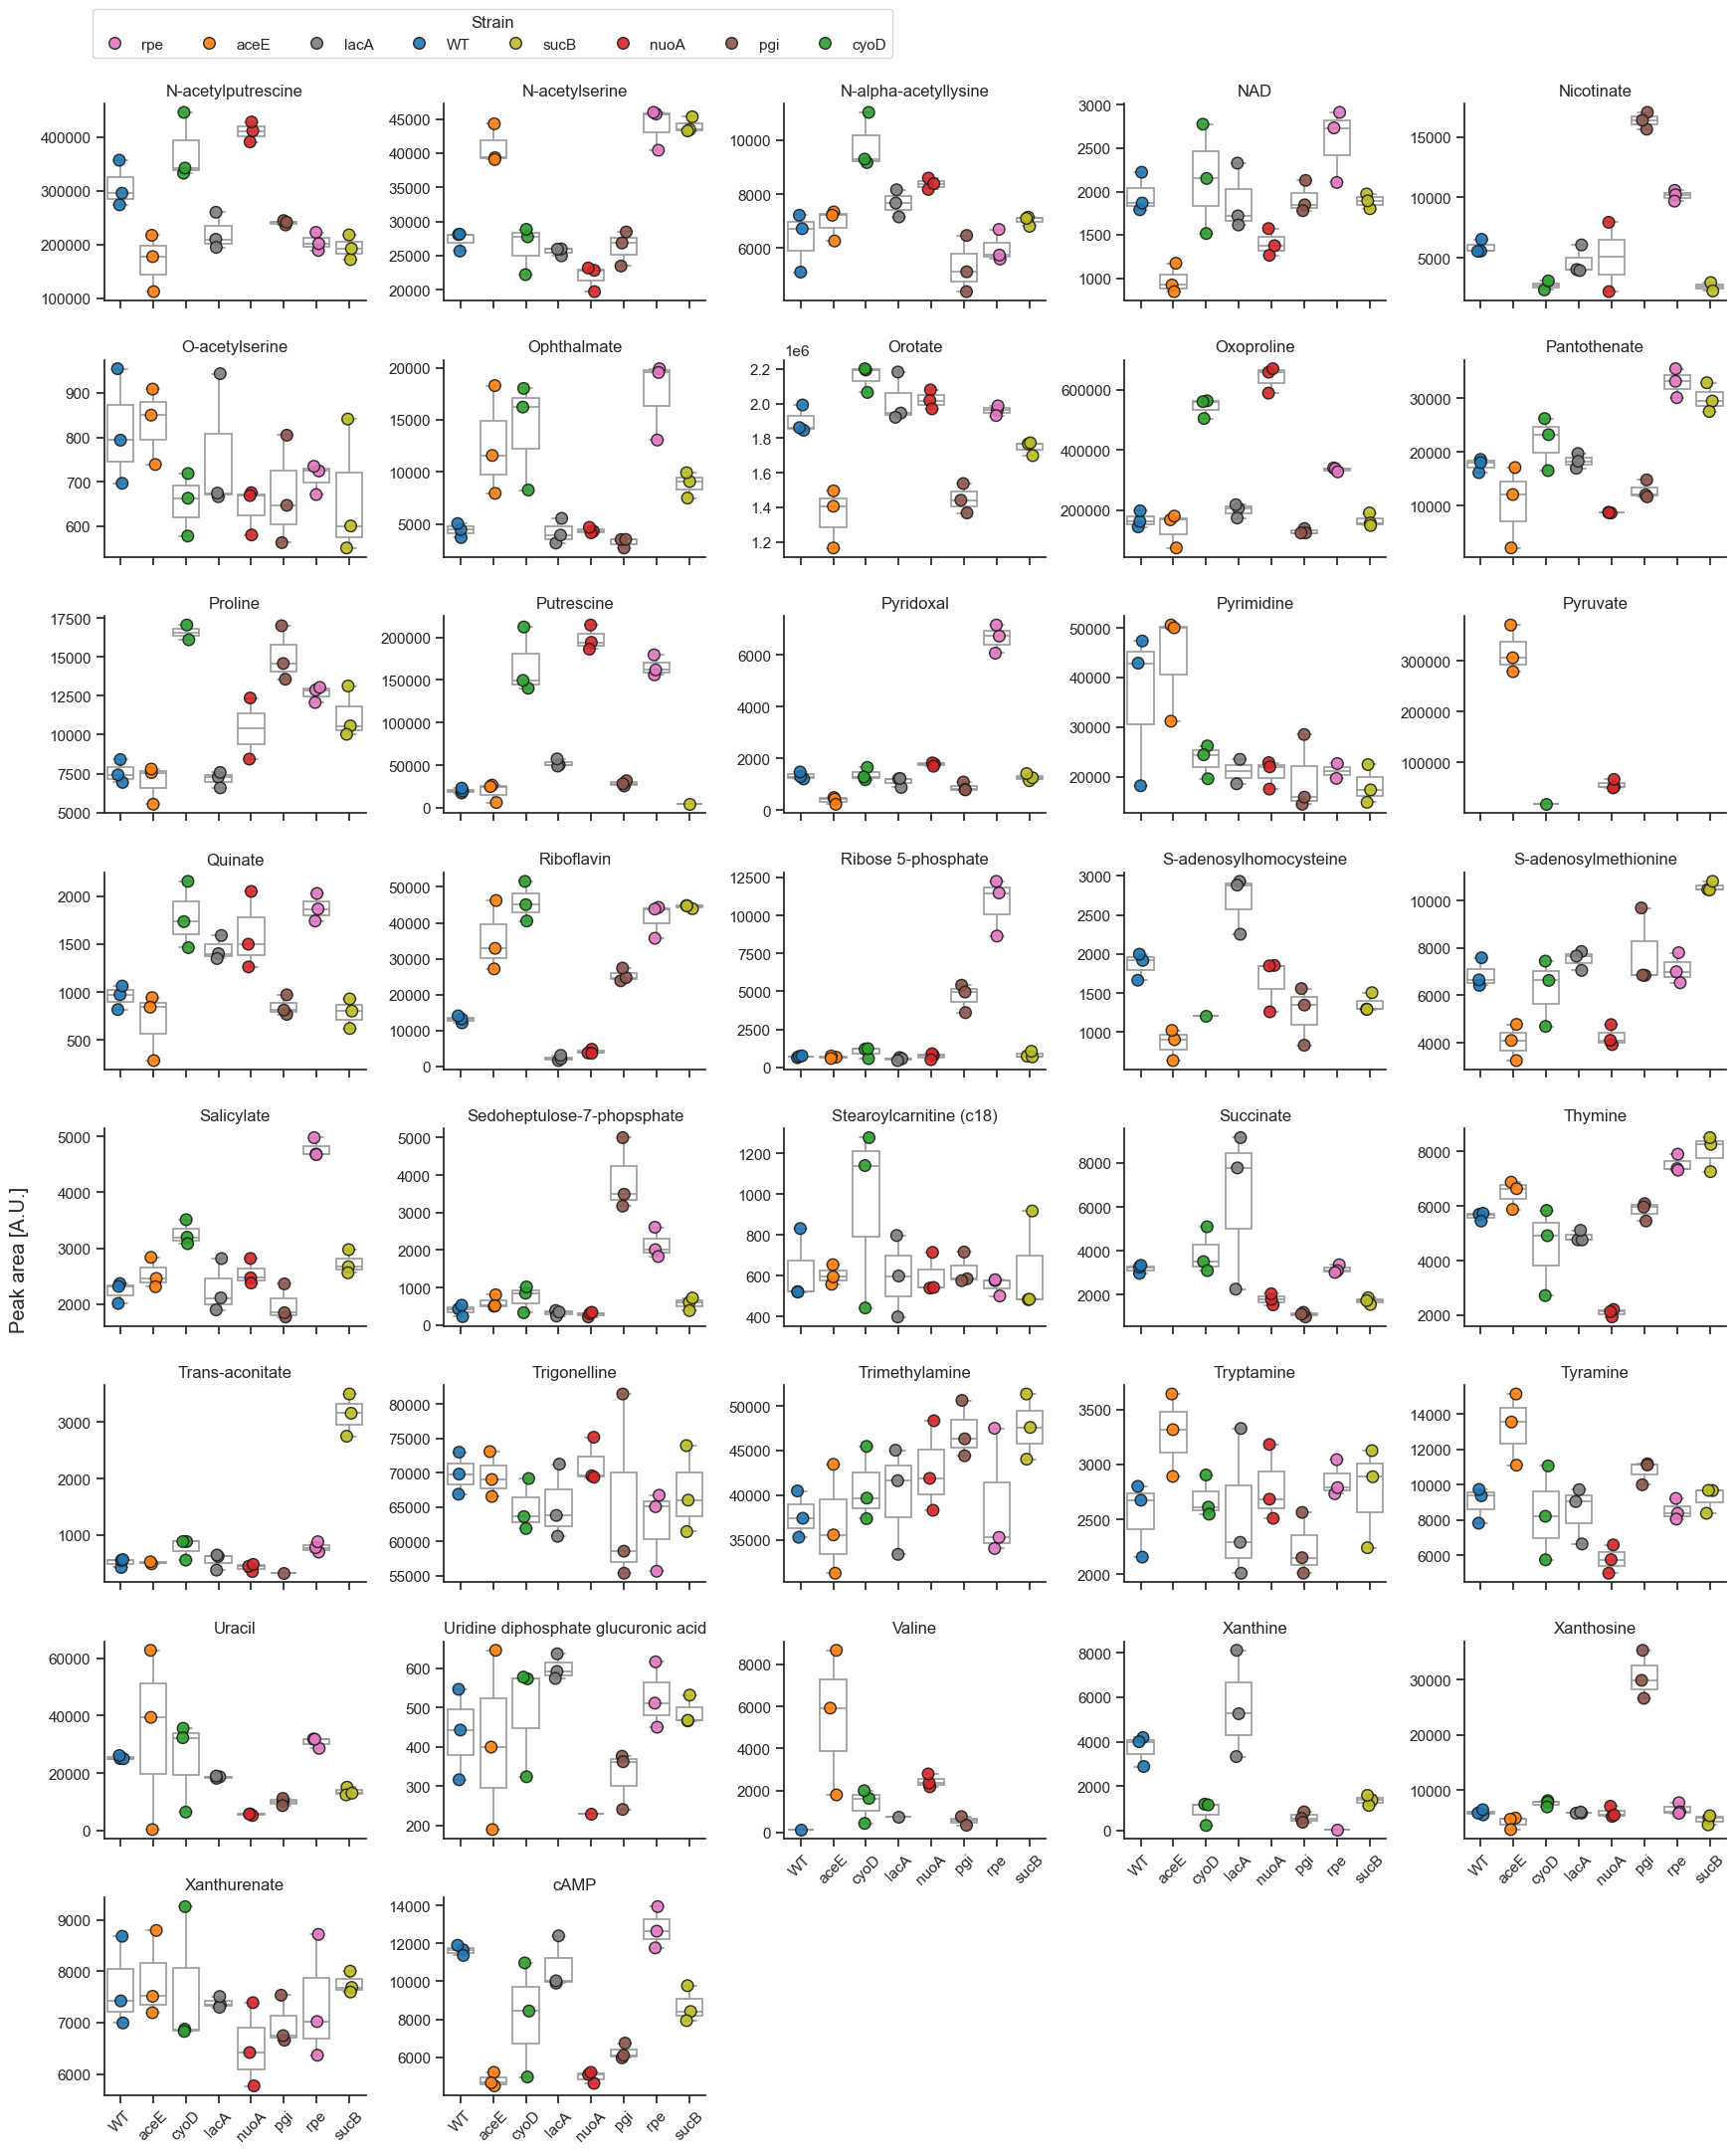

In [115]:
# sns.set_theme(font_scale=1.2, style='ticks')
idx3 = dfL_counts.Metabolite.isin(third)

g = sns.catplot(data = dfL_counts.loc[idx3], x = 'Strain', y = 'Counts', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=5, sharey=False, s = 70, alpha = 0.9, linewidth = 1, edgecolor='k',height=3, aspect=1.2,legend = True)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Counts',color = 'w', fliersize = 0, linewidth = 1.2)
g.set_titles(col_template="{col_name}")
# Rotate x-tick labels for all axes
for ax in g.axes.flat:
    # if (ax.get_ylim()[1]/ax.get_ylim()[0] > 10) or ((ax.get_ylim()[0] <=0) and (ax.get_ylim()[1] > 100)):
    # ax.set_yscale('log')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('center')
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0.06,1), ncol = 8, frameon = True)

g.set_axis_labels('', '')
g.fig.supylabel('Peak area [A.U.]')
plt.subplots_adjust(wspace=0.3, hspace=0.3, left = 0.07, bottom=0.15)
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_3.pdf', bbox_inches='tight')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_counts_3.png', bbox_inches='tight', dpi = 300)

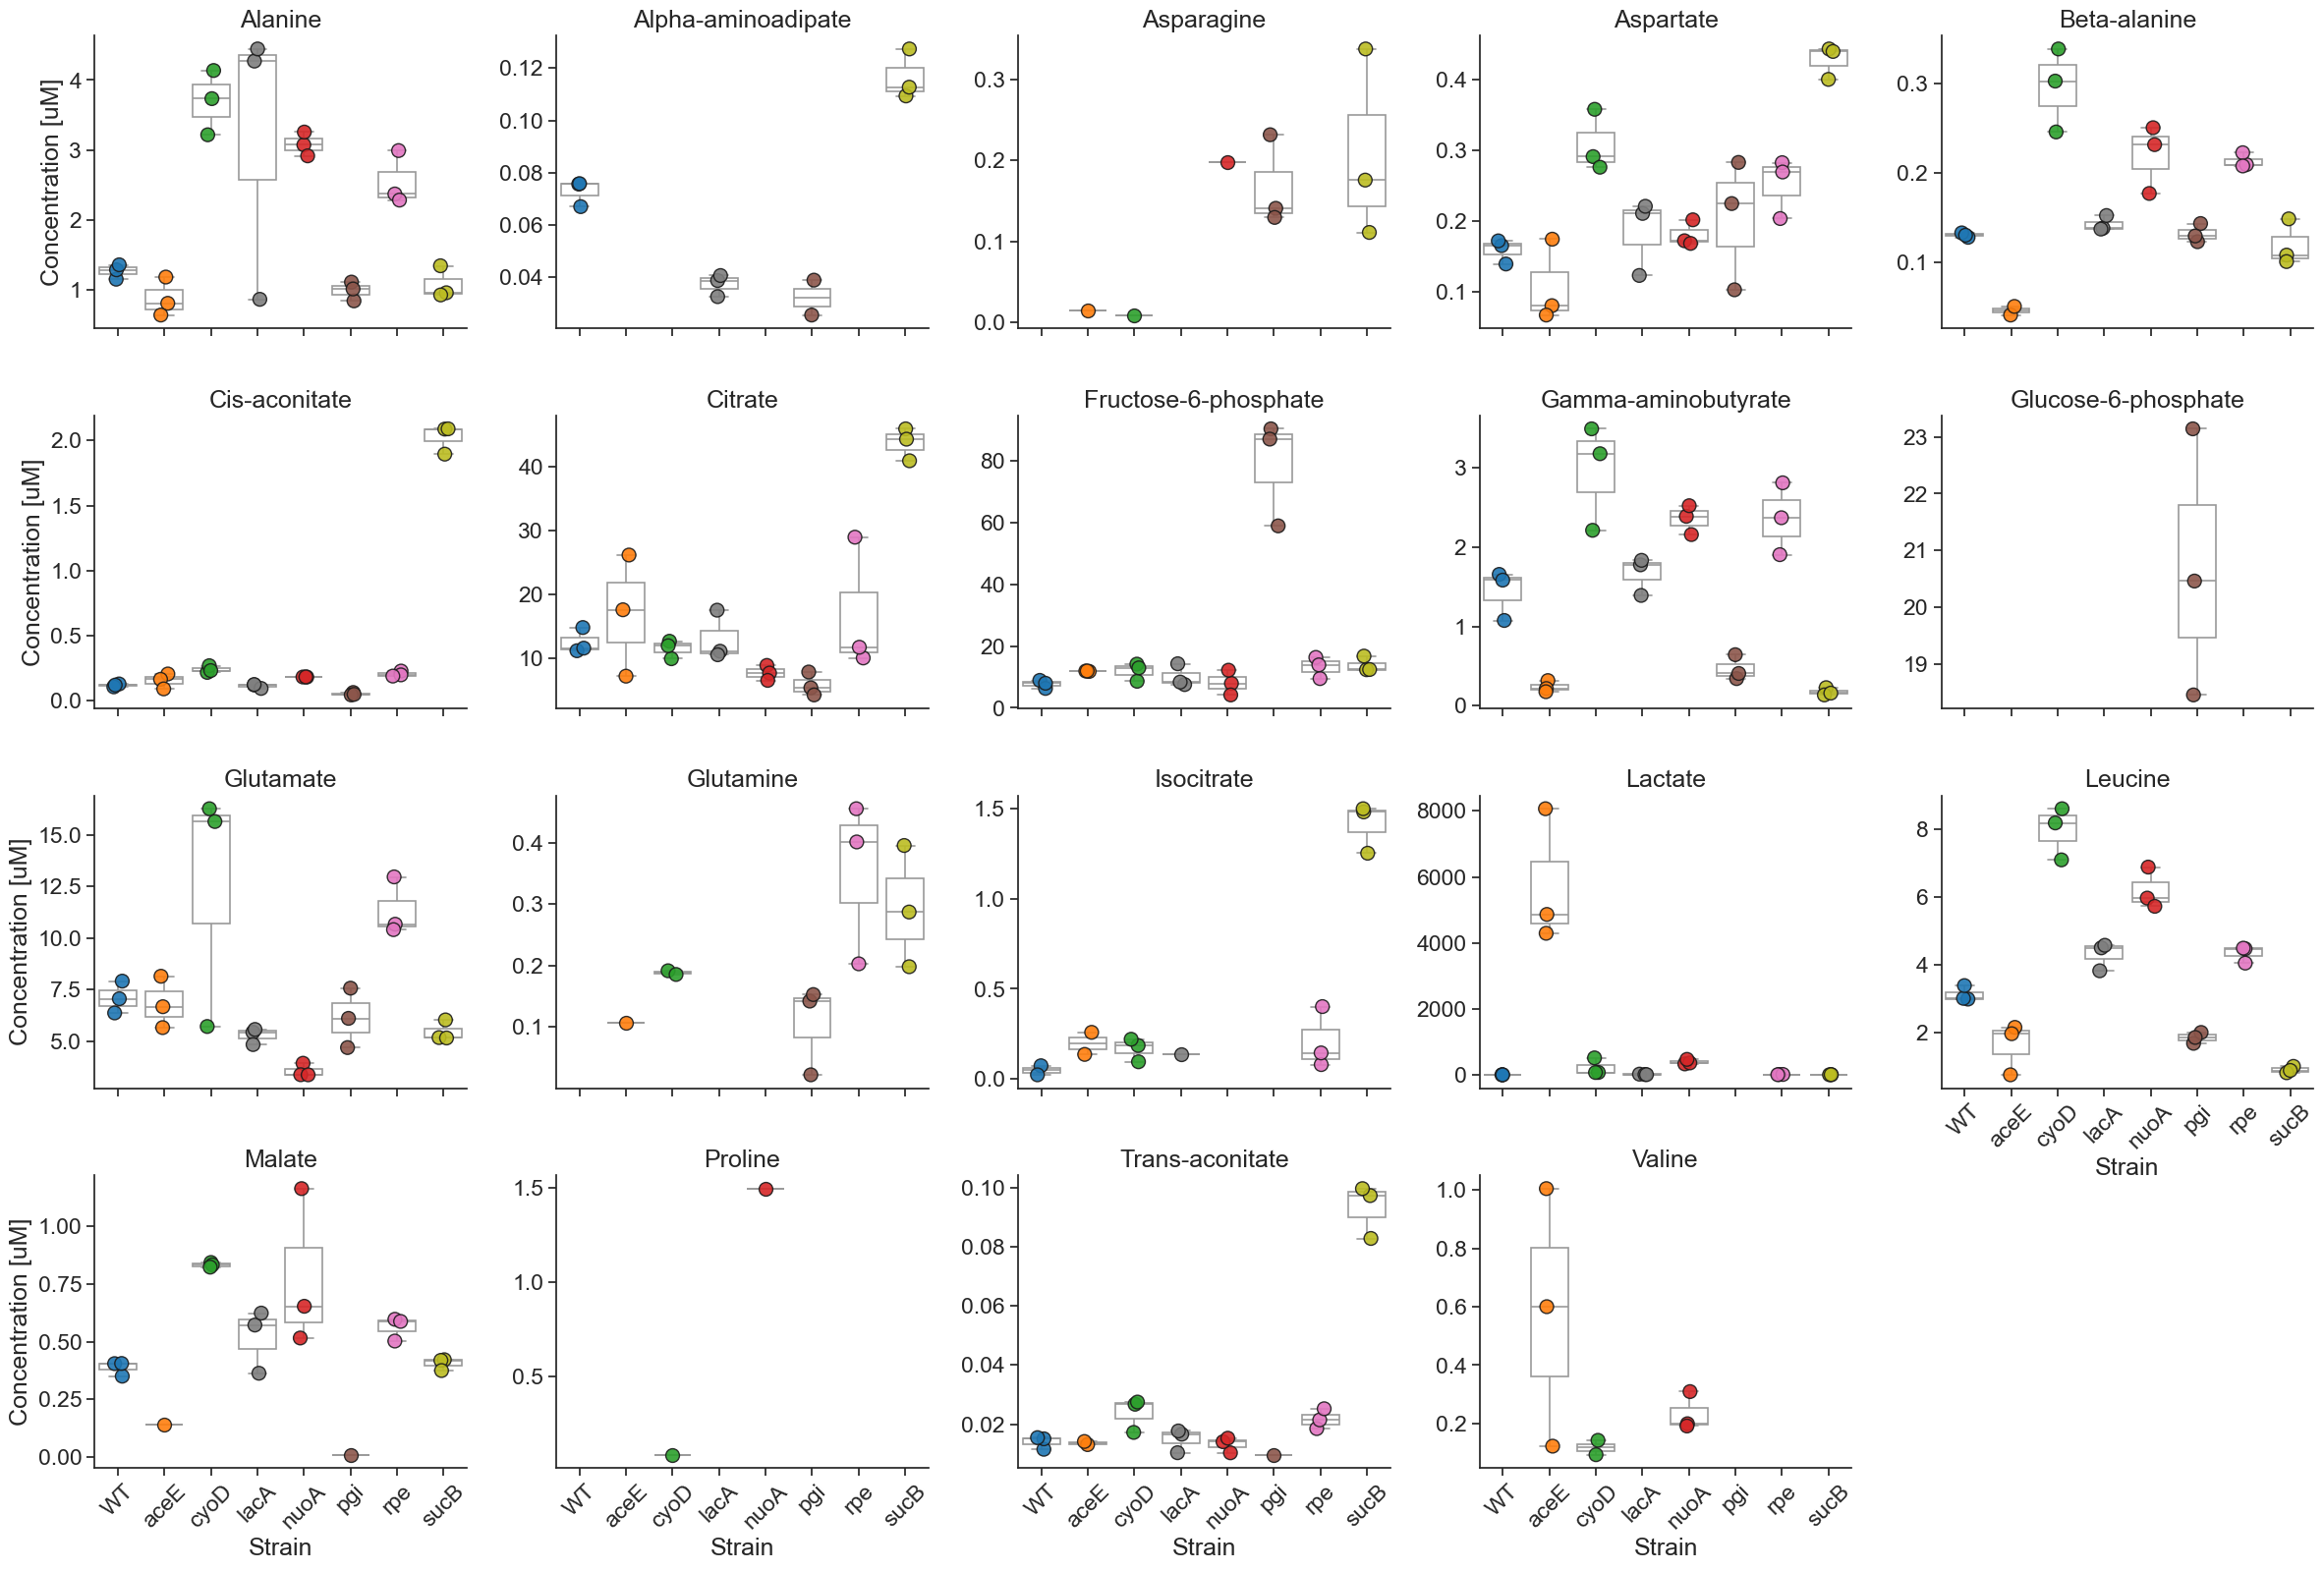

In [116]:
sns.set_theme(font_scale=1.5, style='ticks')
g = sns.catplot(data = dfL_uM, x = 'Strain', y = 'Concentration [uM]', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=5, sharey=False, s = 100, alpha = 0.9, linewidth = 1, edgecolor='k',height=4, aspect=1.2,)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Concentration [uM]',color = 'w', fliersize = 0, linewidth = 1.2)
g.set_titles(col_template="{col_name}")
# Rotate x-tick labels for all axes
for ax in g.axes.flat:
    # if (ax.get_ylim()[1]/ax.get_ylim()[0] > 10) or ((ax.get_ylim()[0] <=0) and (ax.get_ylim()[1] > 100)):
    # ax.set_yscale('log')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('center')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_uM.pdf', bbox_inches='tight')
plt.savefig(figure_folder / 'KEIO_KO_exometabolome_uM.png', bbox_inches='tight', dpi = 300)

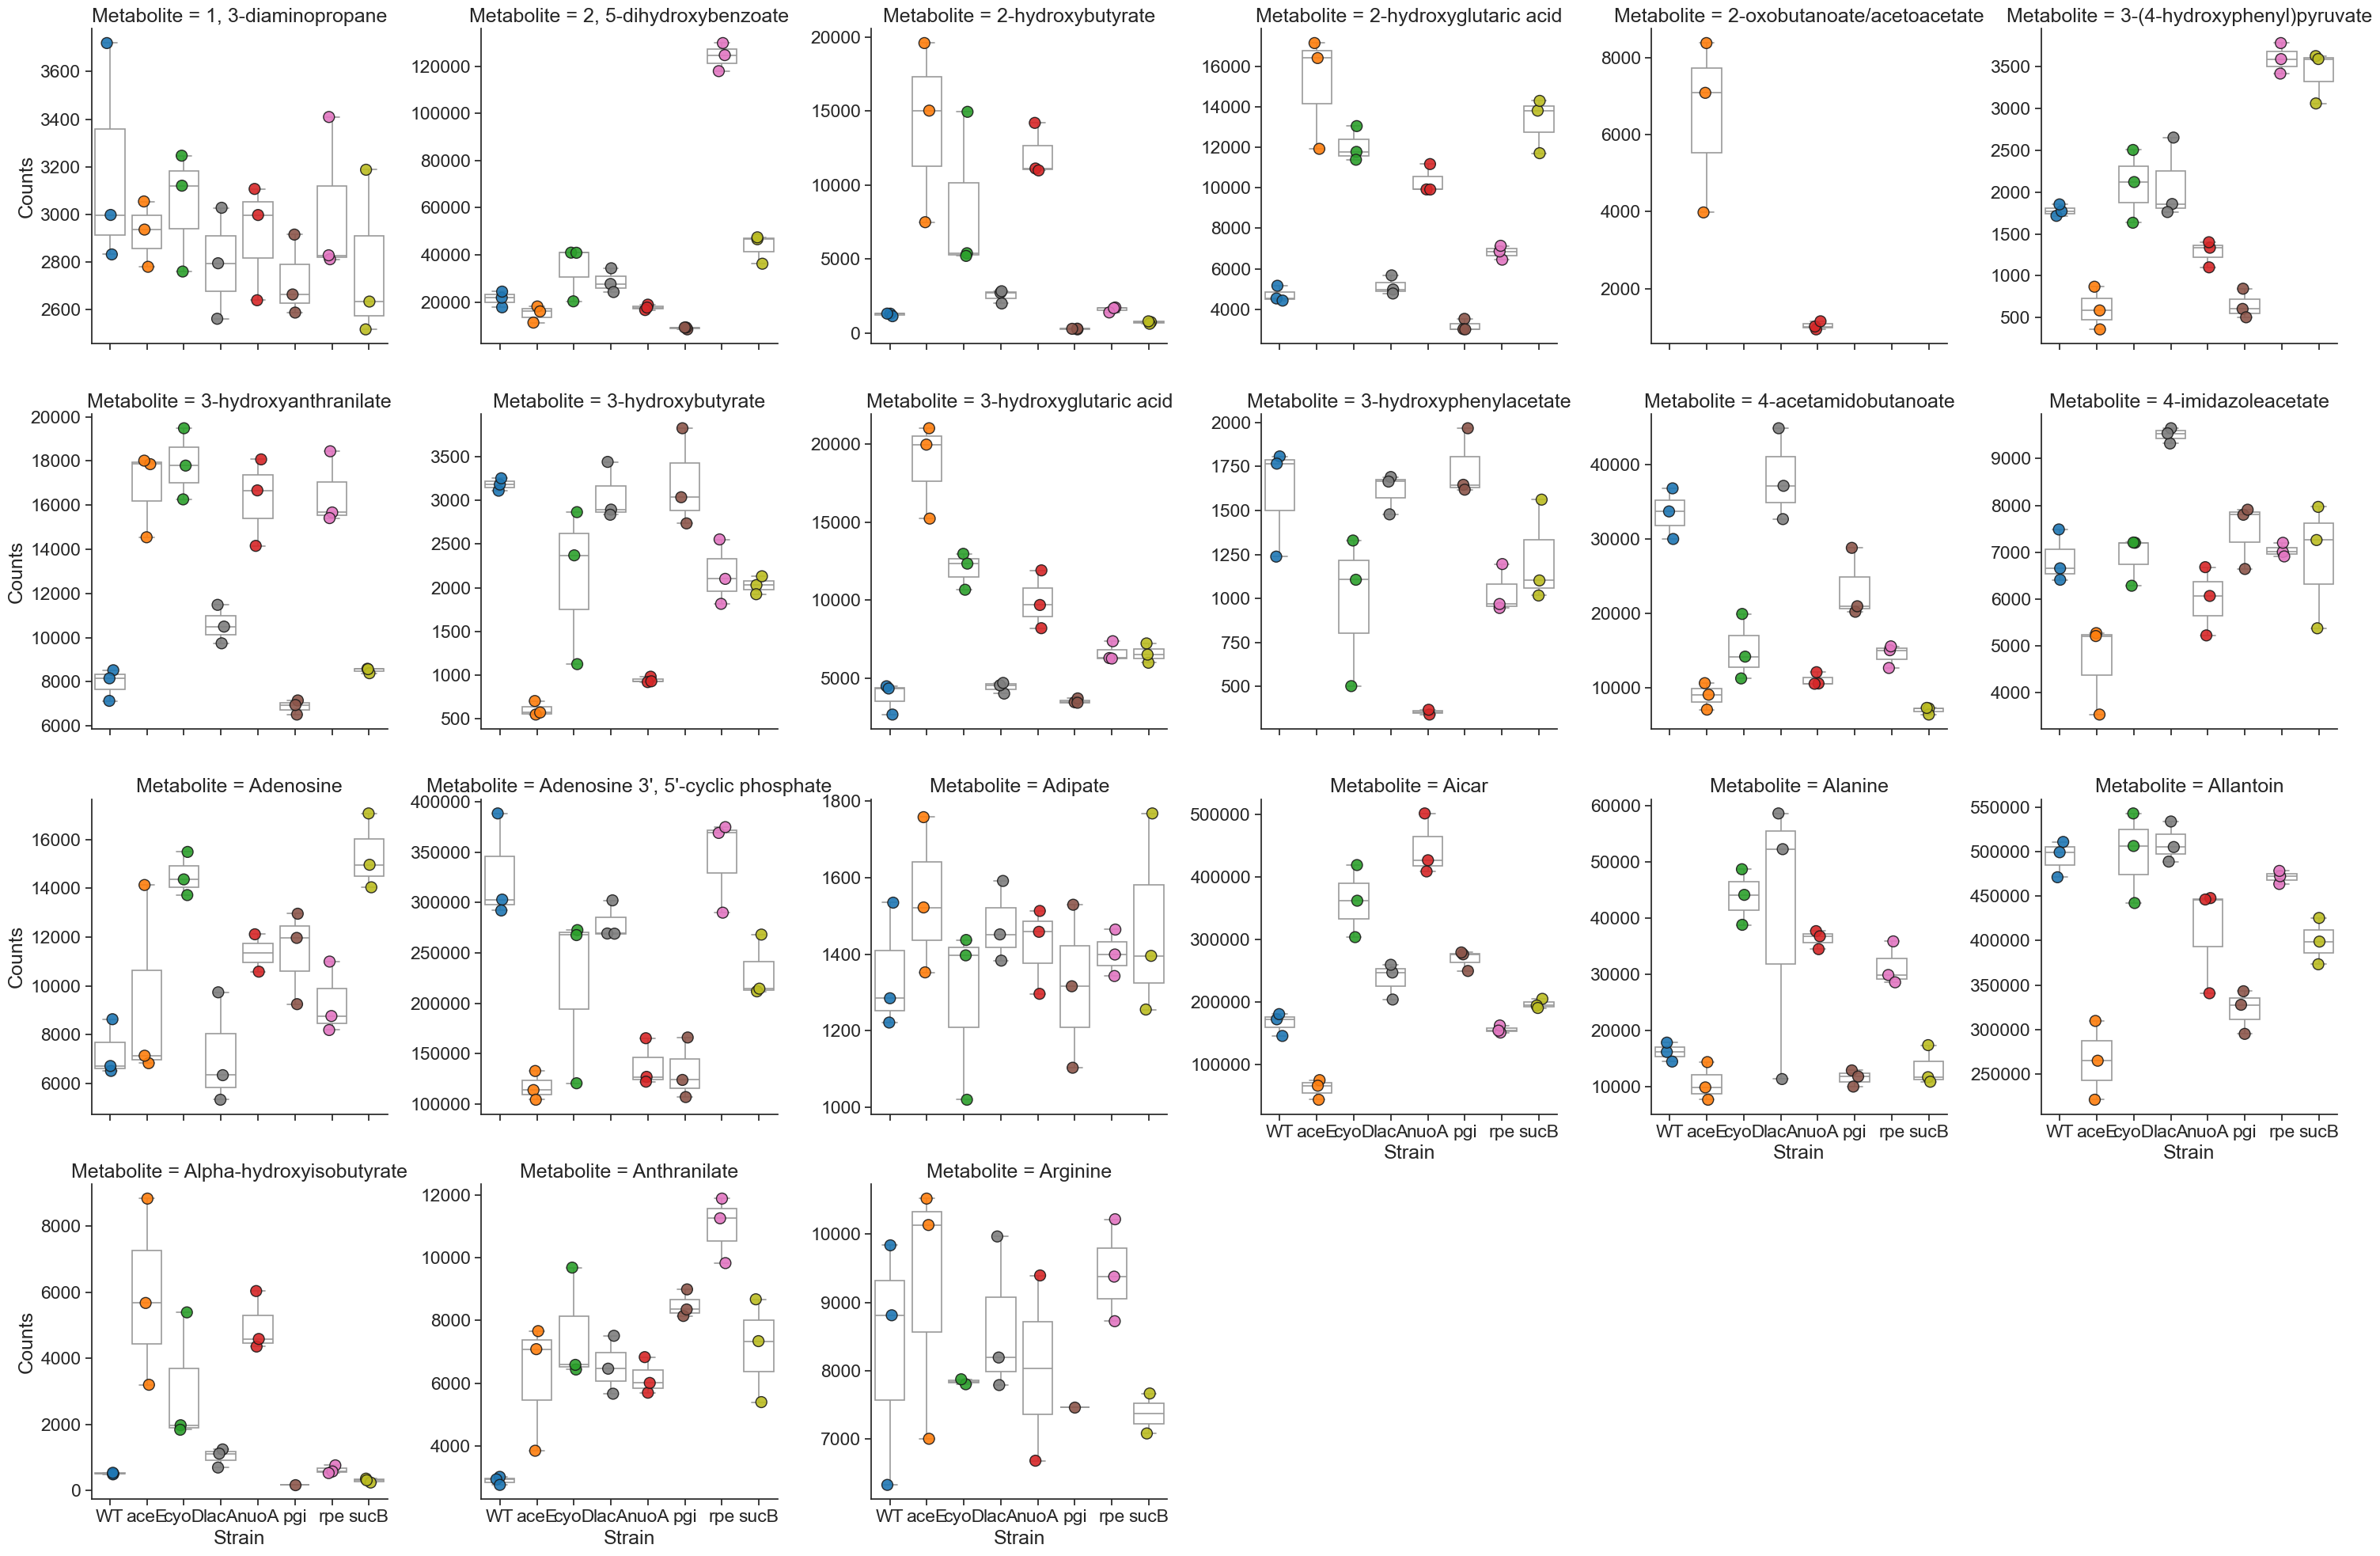

In [117]:
g = sns.catplot(data = dfL_counts.iloc[:500], x = 'Strain', y = 'Counts', hue = 'Strain', order = exo_strains, palette=strain_colors,
            col = 'Metabolite',col_wrap=6, sharey=False, s = 100, alpha = 0.9, linewidth = 1, edgecolor='k',)
g.map_dataframe(sns.boxplot, x = 'Strain', y = 'Counts',color = 'w', fliersize = 0, linewidth = 1.2)

# Read in metabolomics data from Fuhrer et al

In [118]:
metabolomics_folder = Path('../../data/fuhrer_2017/')
neg_zscore = pd.read_csv(metabolomics_folder/'zscore_neg.tsv', sep = '\t', header=None)
pos_zscore = pd.read_csv(metabolomics_folder/'zscore_pos.tsv', sep = '\t', header=None)
zscores = pd.concat([neg_zscore, pos_zscore])
met_info = pd.read_csv(metabolomics_folder / 'metabolite_info.csv')
met_info = met_info.iloc[1:,:4]
sample_info = pd.read_csv(metabolomics_folder / 'strain_ids.csv', header=None)
zscores.columns = [x[0] for x in sample_info.values]

In [119]:
met_info.head(20)

,Ionization Mode,Ion Index,m/z,"Annotations (Compound Name, Modification, Sum-Formula, KEGG Code, HMDB Code)"
1,neg,1.0,56.996,no annotation
2,neg,2.0,57.035,2-Oxobutanoate -CO2-H(+) C4H6O3 C00109 HMDB00005
3,neg,3.0,57.056,no annotation
4,neg,4.0,58.038,Acetone [+1]-H(+) C3H6O C00207 HMDB01659
5,neg,5.0,59.014,Acetate -H(+) C2H4O2 C00033 HMDB00042
6,neg,6.0,59.050,4-Hydroxybutanoic acid -CO2-H(+) C4H8O3 C00989...
7,neg,7.0,59.071,no annotation
8,neg,8.0,59.105,no annotation
9,neg,9.0,59.146,no annotation
10,neg,10.0,59.986,HCO3- -H(+) HCO3 C00288 HMDB00595


In [120]:
for i, row in met_info.iterrows():
    annotations = row['Annotations (Compound Name, Modification, Sum-Formula, KEGG Code, HMDB Code)'].split(' ')
    if annotations[0] == 'no':
        continue
    else:
        if len(annotations) > 5:
            j = len(annotations) - 5
            name = ' '.join(annotations[:j+1])
            print(name)
        elif len(annotations) == 5:
            name = annotations[0]
            j = 0

        if len(annotations) >= 5:
            met_info.at[i, 'Name'] = name
            met_info.at[i, 'Sum-Formula'] = annotations[2+j]
            met_info.at[i, 'KEGG Code'] = annotations[3+j]
            met_info.at[i, 'HMDB Code'] = annotations[4+j]
        else:
            break


4-Hydroxybutanoic acid
Carbonic acid
Butanoic acid
3-Methyl-2-oxobutanoic acid
L-Aspartate 4-semialdehyde
Carbonic acid
Ethylene glycol
Butanoic acid
Glycerone phosphate
3-Methylbutanoic acid
4-Hydroxybutanoic acid
Benzyl alcohol
3-Methyl-2-oxobutanoic acid
3-Methyl-2-oxobutanoic acid
Benzyl alcohol
Octanoic acid
3-Methyl-2-oxobutanoic acid
Coniferyl alcohol
3-Methyl-2-oxobutanoic acid
Acetyl phosphate
Choline phosphate
2-Hydroxymuconate semialdehyde
cis-2-Carboxycyclohexyl-acetic acid
Octanoic acid
Octanoic acid
Cinnamyl alcohol
3-(Methylthio)propionic acid
Acetyl phosphate
Nitrous oxide
2-Hydroxymuconate semialdehyde
Sinapyl alcohol
Glycerone phosphate
9-Oxononanoic acid
Coniferyl aldehyde
Coniferyl alcohol
Carbonic acid
Ethylene glycol
Choline phosphate
Glycerone phosphate
sn-Glycerol 3-phosphate
Decanoic acid
D-Gluconic acid
Carbonic acid
Coniferyl alcohol
D-Erythrose 4-phosphate
Coniferyl aldehyde
Decahydro-2-naphthoic acid
Dodecanoic acid
Dihydroclavaminic acid
Dodecanoic acid
D-

In [121]:
zscores.index = met_info.Name

In [122]:
met_info['Name'].to_csv(metabolomics_folder / 'metabolite_names.csv', index = False)

In [123]:
pd.Series(z_metabolites).to_csv(data_folder_1 / 'metabolite_names.csv', index = False)

## Map 


In [124]:
# Redo mapping, only focusing on protonated metabolites 

In [125]:
metabolite_mapping = pd.read_csv(metabolomics_folder/'metabolite_mapping.csv').iloc[:, :2]
metabolite_mapping.columns = ['Ex name', 'In name']

In [126]:
met_map = metabolite_mapping.set_index('Ex name')['In name'].to_dict()

In [127]:
data_comp = []
for strain in exo_strains_x_wt:
    for m in z_metabolites:
        m_in = met_map[m]
        ex_zscores = df_z_scores.loc[df_z_scores.Strain == strain, m].mean()
        ex_wt_zscores = df_z_scores.loc[df_z_scores.Strain == 'WT', m].mean()

        in_zscores = zscores.at[m_in, strain]
        in_wt_zscores = zscores.at[m_in, 'wt']
        data_comp.append([strain, m, ex_zscores-ex_wt_zscores, (in_zscores.mean()-in_wt_zscores.mean())])
        

    

In [128]:
zscores.at[m_in, strain]

Name
3',5'-Cyclic AMP    0.5774
3',5'-Cyclic AMP    0.8344
3',5'-Cyclic AMP    0.5725
3',5'-Cyclic AMP    2.3965
3',5'-Cyclic AMP    1.2605
3',5'-Cyclic AMP    1.1067
3',5'-Cyclic AMP    1.0569
Name: lacA, dtype: float64

In [129]:
df_comp = pd.DataFrame(data_comp, columns=['Strain', 'Metabolite', 'Ex', 'In'])
df_comp.dropna(inplace=True)

PearsonRResult(statistic=np.float64(0.09099211498615731), pvalue=np.float64(0.013278648929842412))

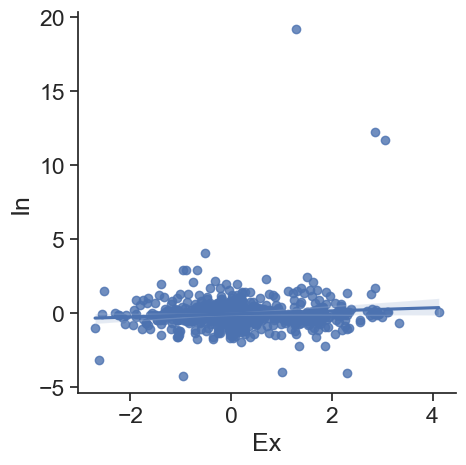

In [130]:
sns.lmplot(data = df_comp, x = 'Ex', y = 'In')
st.spearmanr(df_comp.Ex, df_comp.In)
st.pearsonr(df_comp.Ex, df_comp.In)